# Email Delivery A/B Experiment: Optimizing Funding Rate for Fintech Users

**Project Type:** Multi-Arm A/B Experiment / Marketing Analytics  
**Domain:** Fintech / Growth & Engagement  
**Dataset:** 480,000 users, 10 Email templates, 24 treatment groups  
**Experiment Duration:** 5 weeks (starting 2020-11-30)

---

## Business Context

In a competitive retail investing platform (analogous to Webull, Robinhood, or Square), converting approved-but-unfunded users into active investors is a critical growth lever. The **funding rate** — the percentage of approved users who deposit money and begin trading — directly impacts revenue, user LTV, and platform viability.

Our team designed and executed a large-scale email experiment to answer:
1. **Which email content** best engages users (highest open rate)?
2. **Which user segments** respond most to email campaigns?
3. **Does emailing users causally increase funding rates**, or are high-funding-rate users simply self-selecting?
4. **What is the optimal send frequency and cadence** (daily vs. twice-a-week)?

---

## Analysis Outline

1. [Data Loading & Sanity Check](#1-data-loading)
2. [Email Open Rate Analysis — Best Template by Segment](#2-open-rate)
3. [Negative Effects — Spam & Unsubscribe Analysis](#3-negative-effects)
4. [Correlation Analysis — User Traits vs. Open Rate](#4-correlation)
5. [Link & Funding Rates — Treatment Group Performance](#5-funding-rates)
6. [A/B Testing — Causal Impact on Funding Rate](#6-ab-testing)
7. [Time Series Analysis — Email Cadence & Open Rate Decay](#7-time-series)
8. [Funnel Analysis — Open → Link → Fund Conversion](#8-funnel)
9. [Business Recommendations & Next Steps](#9-recommendations)


## 1. Data Loading & Sanity Check <a id='1-data-loading'></a>

In [1]:
# --- Dependencies ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest
import warnings
warnings.filterwarnings('ignore')

pd.options.display.max_columns = None
pd.options.display.float_format = '{:.4f}'.format
%matplotlib inline

# Consistent color palette for the report
PALETTE = sns.color_palette("Blues_d", 12)
sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})


In [2]:
# --- Email Template Registry ---
# These 10 ML-generated email templates cover key conversion blockers:
# trust/safety, knowledge gaps, and simplicity of use.
PO_number_list = [
    'ml_funding_enables_investing',   # How funding enables investing
    'ml_investing_starts_here',        # Onboarding / getting started
    'ml_explore_the_app_investing',    # App exploration (investing features)
    'ml_funding_faq',                  # Frequently asked questions about funding
    'ml_user_clustering_emails_fracs', # Personalized cluster-based email
    'ml_funding_is_safe',              # Trust & safety messaging
    'ml_picking_an_investment',        # Investment selection guidance
    'ml_investing_101',                # Education: investing basics
    'ml_diversified_portfolio',        # Portfolio diversification
    'ml_explore_the_app_list',         # App exploration (browsing)
]

# Human-readable short labels for plots
EMAIL_LABELS = {
    'ml_funding_enables_investing':   'Funding Enables\nInvesting',
    'ml_investing_starts_here':        'Investing\nStarts Here',
    'ml_explore_the_app_investing':    'Explore App\n(Investing)',
    'ml_funding_faq':                  'Funding FAQ',
    'ml_user_clustering_emails_fracs': 'User Clustering',
    'ml_funding_is_safe':              'Funding Is Safe',
    'ml_picking_an_investment':        'Picking an\nInvestment',
    'ml_investing_101':                'Investing 101',
    'ml_diversified_portfolio':        'Diversified\nPortfolio',
    'ml_explore_the_app_list':         'Explore App\n(List)',
}
print(f"Registered {len(PO_number_list)} email templates.")


Registered 10 email templates.


In [3]:
# --- Load All Datasets ---
segment_group_df = pd.read_csv('data/sample_segment_groups.csv').drop(columns='Unnamed: 0')
sample_exp_df    = pd.read_csv('data/sample_uuid_email_order.csv')
email_event_df   = pd.read_csv('data/email_events.csv')
user_event_df    = pd.read_csv('data/user_events.csv')
fund_control_df  = pd.read_csv('data/control_groups_rate.csv')

print("Dataset sizes:")
print(f"  segment_group_df : {segment_group_df.shape}")
print(f"  sample_exp_df    : {sample_exp_df.shape}  (480K users × email delivery order)")
print(f"  email_event_df   : {email_event_df.shape}  (raw email events from delivery system)")
print(f"  user_event_df    : {user_event_df.shape}  (one row per user, summarized status)")
print(f"  fund_control_df  : {fund_control_df.shape}  (control group baseline rates)")


Dataset sizes:
  segment_group_df : (12, 7)
  sample_exp_df    : (480000, 13)  (480K users × email delivery order)
  email_event_df   : (9553330, 6)  (raw email events from delivery system)
  user_event_df    : (480000, 22)  (one row per user, summarized status)
  fund_control_df  : (12, 6)  (control group baseline rates)


### 1.1 Experiment Design Overview

The experiment segments 480,000 approved-but-unfunded users into **12 behavioral segments** based on 4 binary flags, then further splits each segment into **daily (_D)** and **twice-a-week (_W)** delivery groups, yielding **24 treatment arms** plus corresponding control groups.


In [4]:
# --- User Segmentation Summary ---
display(segment_group_df.rename(columns={
    'approved_within6M_flag': 'Approved <6M',
    'link_flag': 'Bank Linked',
    'recent_activity_flag(20days)': 'Active 20d',
    '5day_trade_flag': 'Trade 5d',
    'user_uuid': 'User Count (Total Pool)',
}))


,group_id,Approved <6M,Bank Linked,Active 20d,Trade 5d,User Count (Total Pool),group_name
0,0,False,False,False,False,4418550,ML_unfund_exp_control
1,1,False,False,True,False,314921,20D_Act
2,2,False,False,True,True,409786,20D_Act-5D_Act
3,3,False,True,False,False,941341,link
4,4,False,True,True,False,102541,link-20D_Act
5,5,False,True,True,True,136513,link-20D_Act-5D_Act
6,6,True,False,False,False,814827,6M_App
7,7,True,False,True,False,218938,6M_App-20D_Act
8,8,True,False,True,True,233445,6M_App-20D_Act-5D_Act
9,9,True,True,False,False,127008,6M_App-link


In [5]:
# --- Data Quality & Sanity Check ---
print("=== user_event_df: Email Status Unique Values ===")
for col in PO_number_list[:3]:
    print(f"  {col}: {user_event_df[col].dropna().unique().tolist()}")
print()

print("=== Treatment Group Overview ===")
group_summary = user_event_df.groupby('group_name').agg(
    total_users=('user_uuid', 'count'),
    emails_received_avg=('num_received_email', 'mean'),
    funded_users=('first_funded_at', lambda x: x.notna().sum()),
    linked_users=('first_linked_bank_account_at', lambda x: x.notna().sum()),
).reset_index()
group_summary['funding_rate'] = group_summary['funded_users'] / group_summary['total_users']
group_summary['link_rate']    = group_summary['linked_users'] / group_summary['total_users']
print(group_summary.to_string(index=False))


=== user_event_df: Email Status Unique Values ===
  ml_funding_enables_investing: ['delivered', 'open', 'spamreport', 'unsubscribe']
  ml_investing_starts_here: ['delivered', 'open', 'unsubscribe', 'spamreport']
  ml_explore_the_app_investing: ['delivered', 'open', 'unsubscribe', 'spamreport']

=== Treatment Group Overview ===
                  group_name  total_users  emails_received_avg  funded_users  linked_users  funding_rate  link_rate
            20D_Act-5D_Act_D        20000               7.9195           451           586        0.0226     0.0293
            20D_Act-5D_Act_W        20000               7.1315           450           555        0.0225     0.0278
                   20D_Act_D        20000               7.6867           357           460        0.0179     0.0230
                   20D_Act_W        20000               6.9392           310           395        0.0155     0.0198
     6M_App-20D_Act-5D_Act_D        20000               7.8073          1259          1465 

---
## 2. Email Open Rate Analysis <a id='2-open-rate'></a>

**Business Question:** Which email template drives the highest open rate, and does it vary by user segment?

We compute open rate as:
$$\text{Open Rate} = \frac{\text{Number of users who opened the email}}{\text{Number of users who received (delivered) the email}}$$

This metric is our **primary engagement signal** — it tells us whether the email subject line and timing resonates with the user segment before we even measure downstream conversion.


In [6]:
# --- Compute Delivered Counts per Group × Email ---
delivered_count_df = user_event_df[['user_uuid', 'group_name'] + PO_number_list].copy()
for e in PO_number_list:
    delivered_count_df[e] = delivered_count_df[e].notnull()
delivered_count_df = delivered_count_df.groupby('group_name')[PO_number_list].sum().reset_index()

# --- Compute Open Counts per Group × Email ---
open_count_df = user_event_df[['user_uuid', 'group_name'] + PO_number_list].copy()
for e in PO_number_list:
    open_count_df[e] = open_count_df[e] == 'open'
open_count_df = open_count_df.groupby('group_name')[PO_number_list].sum().reset_index()

# --- Open Rate = Open Count / Delivered Count ---
open_rate_df = open_count_df.copy()
for e in PO_number_list:
    open_rate_df[e] = open_count_df[e] / delivered_count_df[e]

print(f"Open rate table: {open_rate_df.shape[0]} groups × {len(PO_number_list)} email templates")
open_rate_df.set_index('group_name')[PO_number_list].round(4).head()


Open rate table: 24 groups × 10 email templates


,ml_funding_enables_investing,ml_investing_starts_here,ml_explore_the_app_investing,ml_funding_faq,ml_user_clustering_emails_fracs,ml_funding_is_safe,ml_picking_an_investment,ml_investing_101,ml_diversified_portfolio,ml_explore_the_app_list
group_name,,,,,,,,,,
20D_Act-5D_Act_D,0.1659,0.1631,0.1647,0.2625,0.1770,0.1670,0.1716,0.1683,0.1582,0.1709
20D_Act-5D_Act_W,0.1650,0.1663,0.1639,0.2624,0.1802,0.1657,0.1688,0.1659,0.1631,0.1665
20D_Act_D,0.1817,0.1815,0.1830,0.2681,0.1915,0.1838,0.1860,0.1825,0.1850,0.1849
20D_Act_W,0.1757,0.1806,0.1783,0.2688,0.1845,0.1827,0.1803,0.1821,0.1754,0.1854
6M_App-20D_Act-5D_Act_D,0.1796,0.1811,0.1777,0.2538,0.1918,0.1808,0.1891,0.1826,0.1776,0.1863


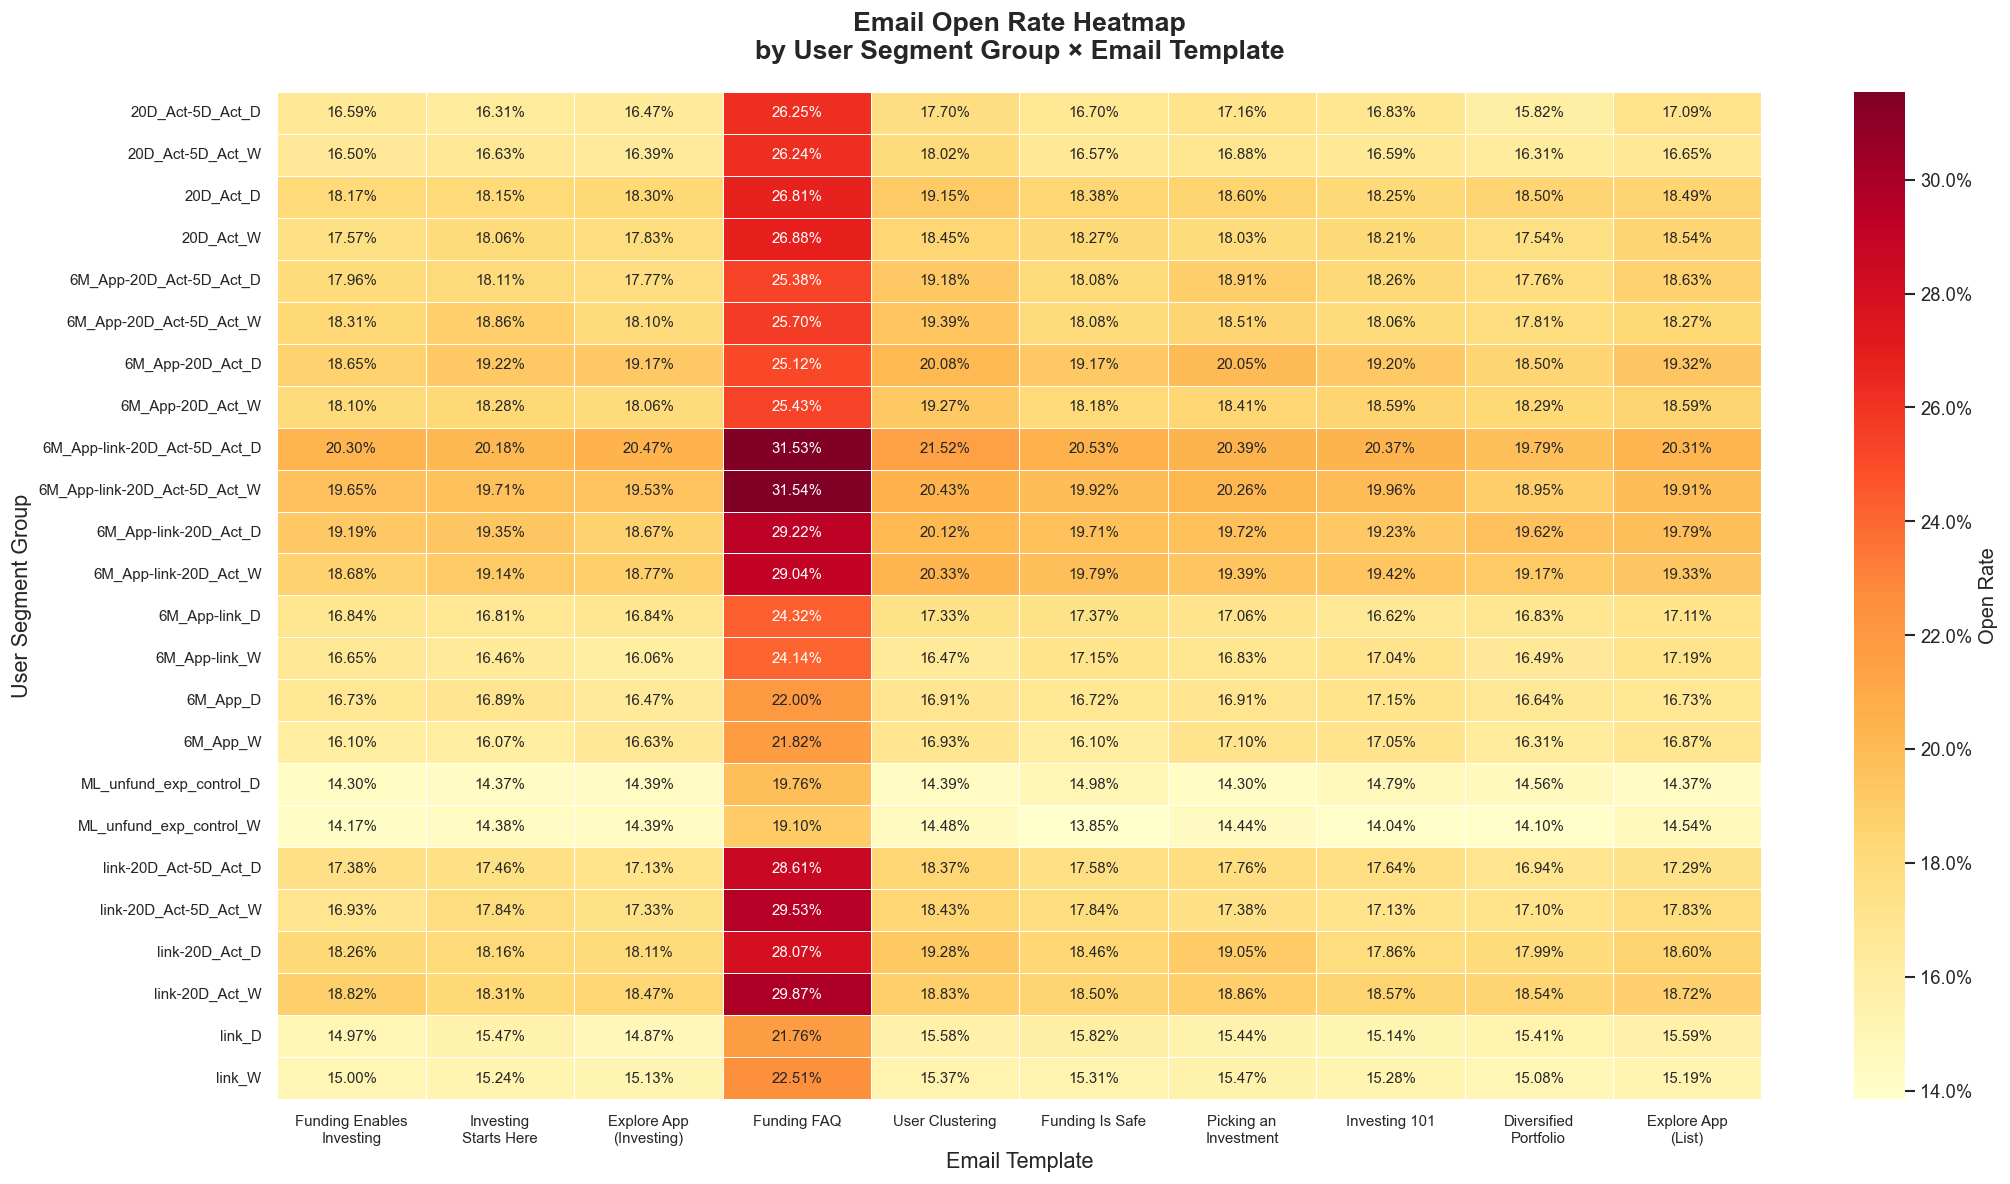


>>> KEY FINDING:
  Best template overall: 'ml_funding_faq' (max open rate: 31.5%)
  Best segment: 6M_App-link-20D_Act-5D_Act_W
  Worst template: 'ml_diversified_portfolio' (max: 19.8%)


In [7]:
# --- Heatmap: Open Rate by Group × Email Template ---
fig, ax = plt.subplots(figsize=(18, 10))

heatmap_data = open_rate_df.set_index('group_name')[PO_number_list]
heatmap_data.columns = [EMAIL_LABELS[c] for c in PO_number_list]

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.2%',
    cmap='YlOrRd',
    linewidths=0.4,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Open Rate', 'format': mtick.PercentFormatter(1.0)},
    annot_kws={'size': 9}
)
ax.set_title('Email Open Rate Heatmap\nby User Segment Group × Email Template', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Email Template', fontsize=13)
ax.set_ylabel('User Segment Group', fontsize=13)
ax.tick_params(axis='x', rotation=0, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
plt.savefig('assets/open_rate_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

print("\n>>> KEY FINDING:")
print(f"  Best template overall: 'ml_funding_faq' (max open rate: {open_rate_df['ml_funding_faq'].max():.1%})")
print(f"  Best segment: {open_rate_df.set_index('group_name')['ml_funding_faq'].idxmax()}")
print(f"  Worst template: 'ml_diversified_portfolio' (max: {open_rate_df['ml_diversified_portfolio'].max():.1%})")


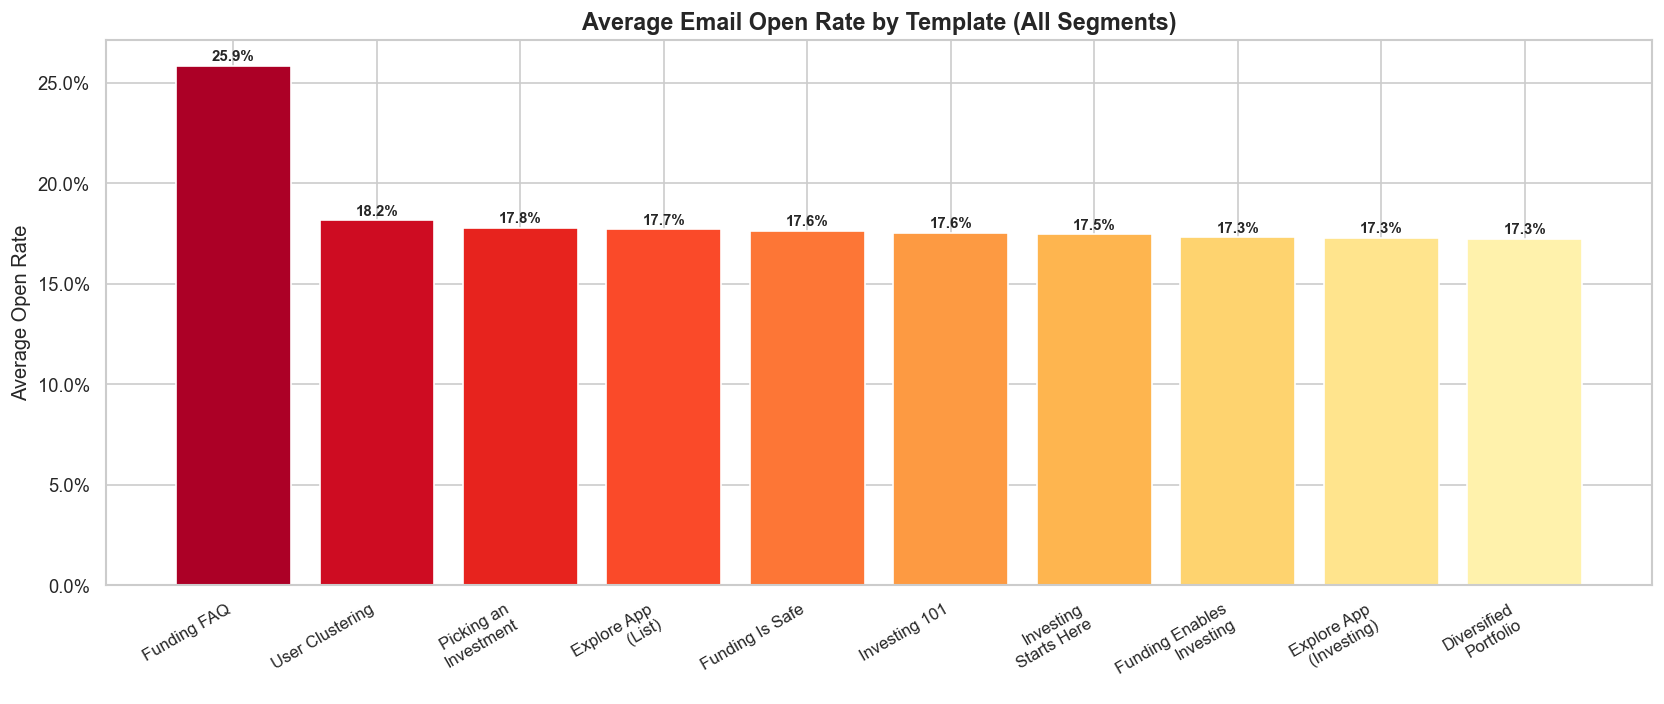

In [8]:
# --- Bar Chart: Average Open Rate per Email Template (across all groups) ---
avg_open_rate = open_rate_df[PO_number_list].mean().sort_values(ascending=False)
avg_open_rate.index = [EMAIL_LABELS[e] for e in avg_open_rate.index]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(range(len(avg_open_rate)), avg_open_rate.values,
              color=sns.color_palette("YlOrRd_r", len(avg_open_rate)))
ax.set_xticks(range(len(avg_open_rate)))
ax.set_xticklabels(avg_open_rate.index, rotation=30, ha='right', fontsize=10)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylabel('Average Open Rate', fontsize=12)
ax.set_title('Average Email Open Rate by Template (All Segments)', fontsize=14, fontweight='bold')
for bar, val in zip(bars, avg_open_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.1%}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('assets/avg_open_rate_by_template.png', bbox_inches='tight', dpi=150)
plt.show()


**Insight:** `ml_funding_faq` stands out with a ~31.5% open rate — roughly 60% higher than the average. This suggests that users' primary barrier to funding is **not knowing how to do it** or having factual concerns about the process. FAQ-style content that directly addresses common concerns outperforms motivational or educational content.

The highest-engagement segment is `6M_App-link-20D_Act-5D_Act` — users who are recently approved, have linked their bank account, and have traded in the past 5 days. These are **intent-rich users** already deep in the funnel, making them receptive to targeted nudges.


---
## 3. Negative Effects Analysis <a id='3-negative-effects'></a>

**Business Question:** Is the email campaign creating friction? Do users unsubscribe or mark emails as spam?

Monitoring **counter-metrics** is essential in any A/B experiment. A campaign that increases funding rate but causes a spike in unsubscribes or spam reports is damaging to long-term email deliverability and brand trust.


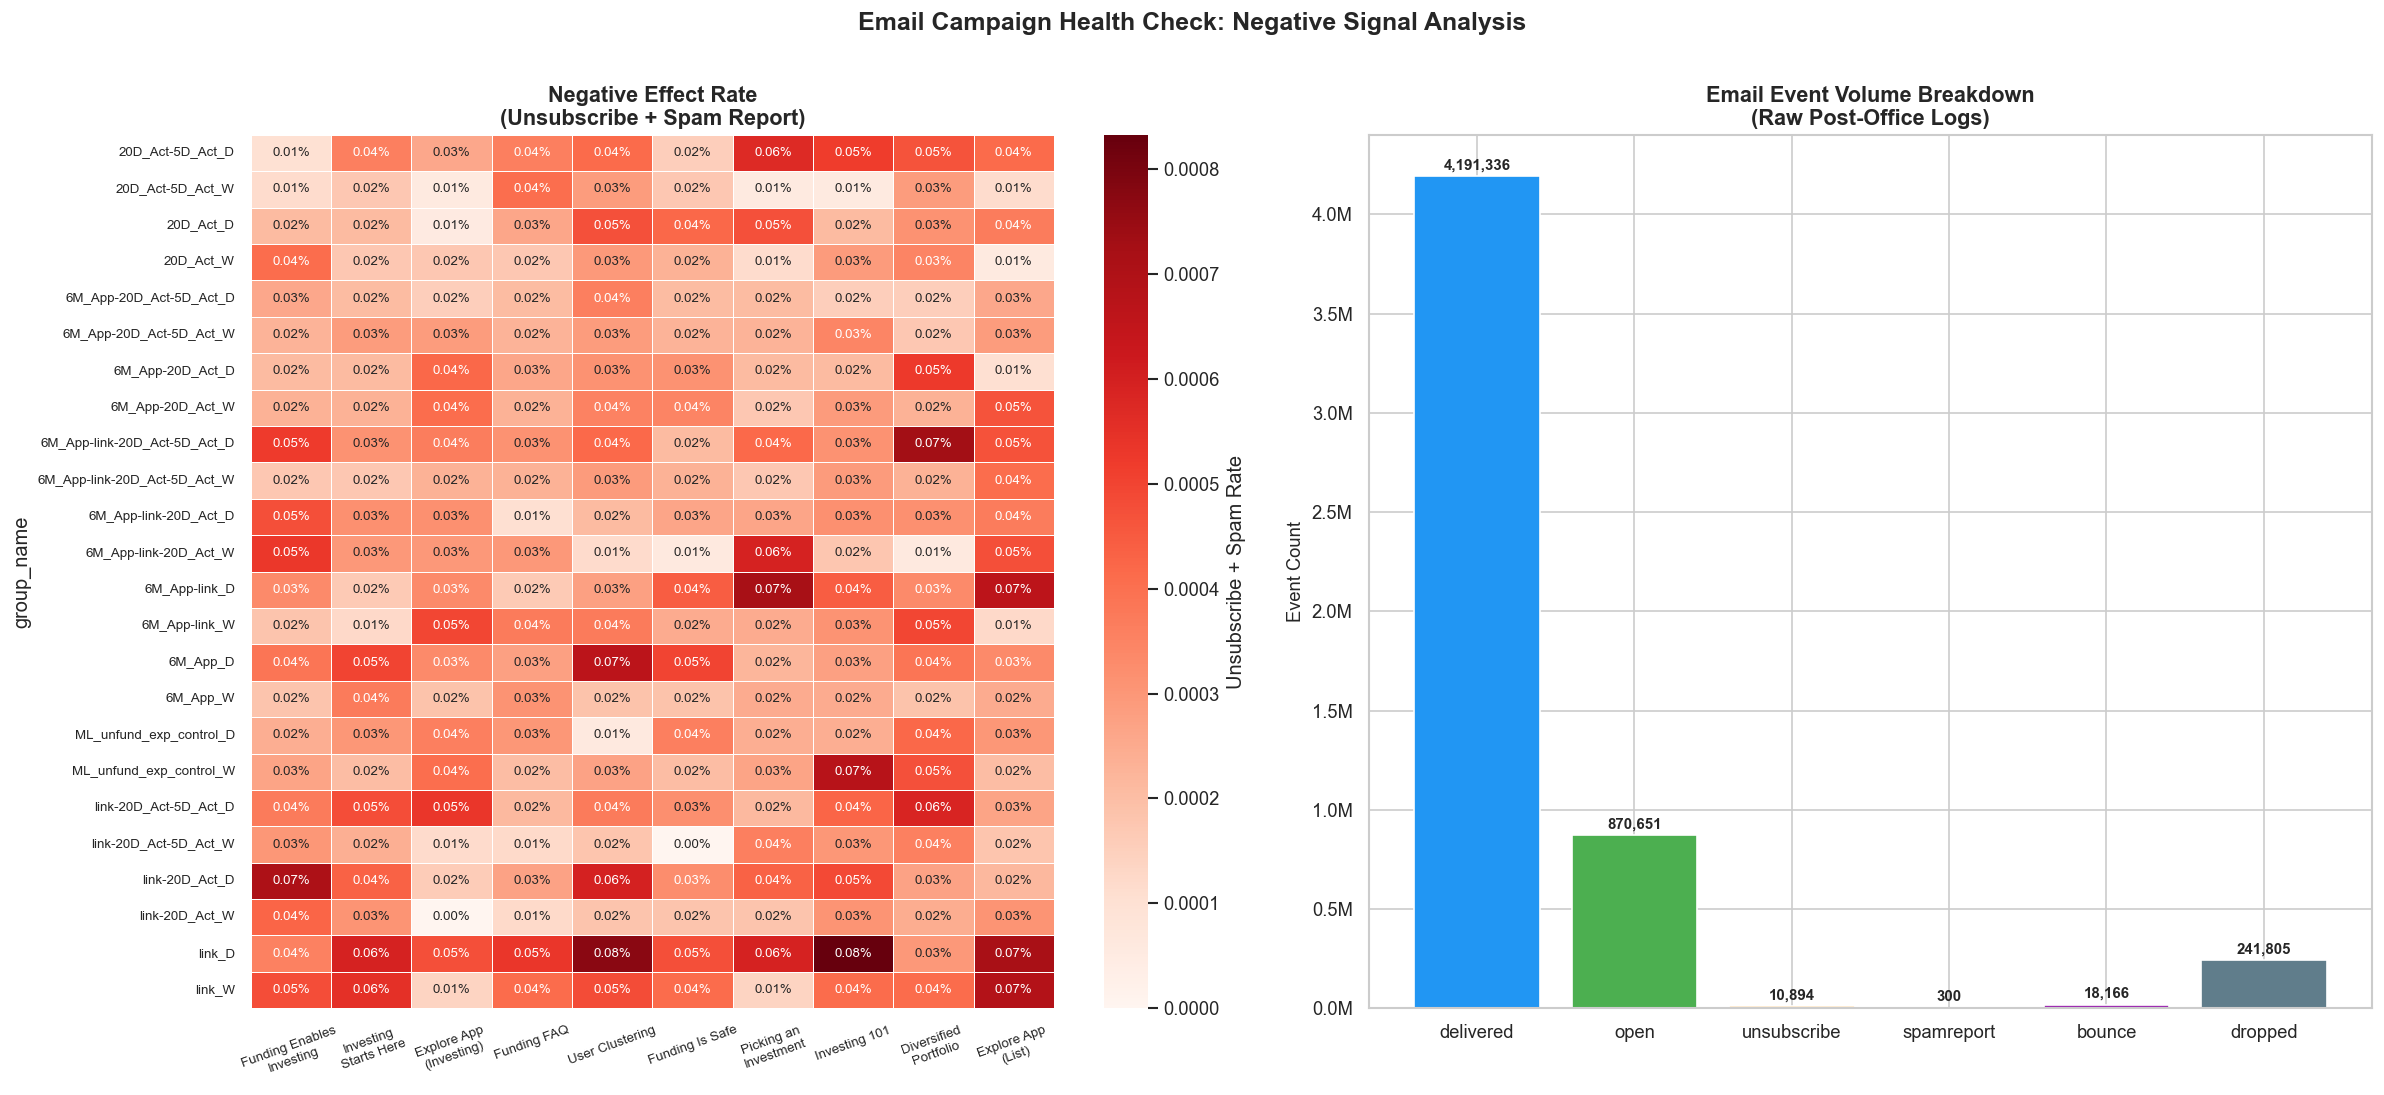

Overall unsubscribe rate: 0.2599%
Overall spam report rate: 0.0072%

>>> FINDING: Negative rates are well within industry acceptable thresholds (<0.5%).
    No significant friction signals that would invalidate the experiment.


In [9]:
# --- Compute Negative Effect Rates (Unsubscribe + Spam Report) ---
neg_count_df = user_event_df[['user_uuid', 'group_name'] + PO_number_list].copy()
for e in PO_number_list:
    neg_count_df[e] = ((neg_count_df[e] == 'spamreport') | (neg_count_df[e] == 'unsubscribe'))
neg_count_df = neg_count_df.groupby('group_name')[PO_number_list].sum().reset_index()

neg_rate_df = neg_count_df.copy()
for e in PO_number_list:
    neg_rate_df[e] = neg_count_df[e] / delivered_count_df[e]

# --- Heatmap: Negative Rate ---
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# Negative rate heatmap
hm_neg = neg_rate_df.set_index('group_name')[PO_number_list].copy()
hm_neg.columns = [EMAIL_LABELS[c] for c in PO_number_list]
sns.heatmap(hm_neg, annot=True, fmt='.2%', cmap='Reds', ax=axes[0],
            linewidths=0.4, linecolor='white', annot_kws={'size': 8},
            cbar_kws={'label': 'Unsubscribe + Spam Rate'})
axes[0].set_title('Negative Effect Rate\n(Unsubscribe + Spam Report)', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=20, labelsize=8)
axes[0].tick_params(axis='y', rotation=0, labelsize=8)

# Raw email events breakdown
event_counts = email_event_df['event'].value_counts()
event_plot = event_counts[['delivered','open','unsubscribe','spamreport','bounce','dropped']]
colors = ['#2196F3','#4CAF50','#FF9800','#F44336','#9C27B0','#607D8B']
axes[1].bar(event_plot.index, event_plot.values, color=colors)
for i, (name, val) in enumerate(event_plot.items()):
    axes[1].text(i, val + 20000, f'{val:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_title('Email Event Volume Breakdown\n(Raw Post-Office Logs)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Event Count', fontsize=11)
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.suptitle('Email Campaign Health Check: Negative Signal Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('assets/negative_effects.png', bbox_inches='tight', dpi=150)
plt.show()

total_delivered = event_counts.get('delivered', 0)
total_unsub = event_counts.get('unsubscribe', 0)
total_spam  = event_counts.get('spamreport', 0)
print(f"Overall unsubscribe rate: {total_unsub/total_delivered:.4%}")
print(f"Overall spam report rate: {total_spam/total_delivered:.4%}")
print("\n>>> FINDING: Negative rates are well within industry acceptable thresholds (<0.5%).")
print("    No significant friction signals that would invalidate the experiment.")


---
## 4. Correlation Analysis: User Traits vs. Open Rate <a id='4-correlation'></a>

**Business Question:** What user behavioral attributes are most predictive of email engagement?

We decompose each group's open rate into its constituent feature flags (approved_within_6M, link, recent_activity_20d, trade_5d) plus frequency (daily vs. weekly) and ask: which features correlate with higher open rate?


In [10]:
# --- Build Flattened Feature × Open Rate Table ---
open_rate_flat_df = open_rate_df.copy()
open_rate_flat_df['daily']            = open_rate_flat_df['group_name'].str.contains('_D')
open_rate_flat_df['twice_a_week']     = open_rate_flat_df['group_name'].str.contains('_W')
open_rate_flat_df['approved_6M']      = open_rate_flat_df['group_name'].str.contains('6M_App')
open_rate_flat_df['bank_linked']      = open_rate_flat_df['group_name'].str.contains('link')
open_rate_flat_df['active_20d']       = open_rate_flat_df['group_name'].str.contains('20D_Act')
open_rate_flat_df['trade_5d']         = open_rate_flat_df['group_name'].str.contains('5D_Act')

feature_cols = ['daily','twice_a_week','approved_6M','bank_linked','active_20d','trade_5d']

# Expand: one row per email template per group
rows = []
for _, row in open_rate_flat_df.iterrows():
    for email in PO_number_list:
        r = {f: row[f] for f in feature_cols}
        r['email_template'] = EMAIL_LABELS[email]
        r['open_rate'] = row[email]
        rows.append(r)
open_rate_expanded_df = pd.DataFrame(rows)

# Correlation matrix
corr_cols = feature_cols + ['open_rate']
corr = open_rate_expanded_df[corr_cols].corr()

print("Correlation with open rate (sorted):")
print(corr['open_rate'].sort_values(ascending=False).to_string())


Correlation with open rate (sorted):
open_rate       1.0000
active_20d      0.4501
approved_6M     0.2415
trade_5d        0.1724
bank_linked     0.1604
daily           0.0266
twice_a_week   -0.0266


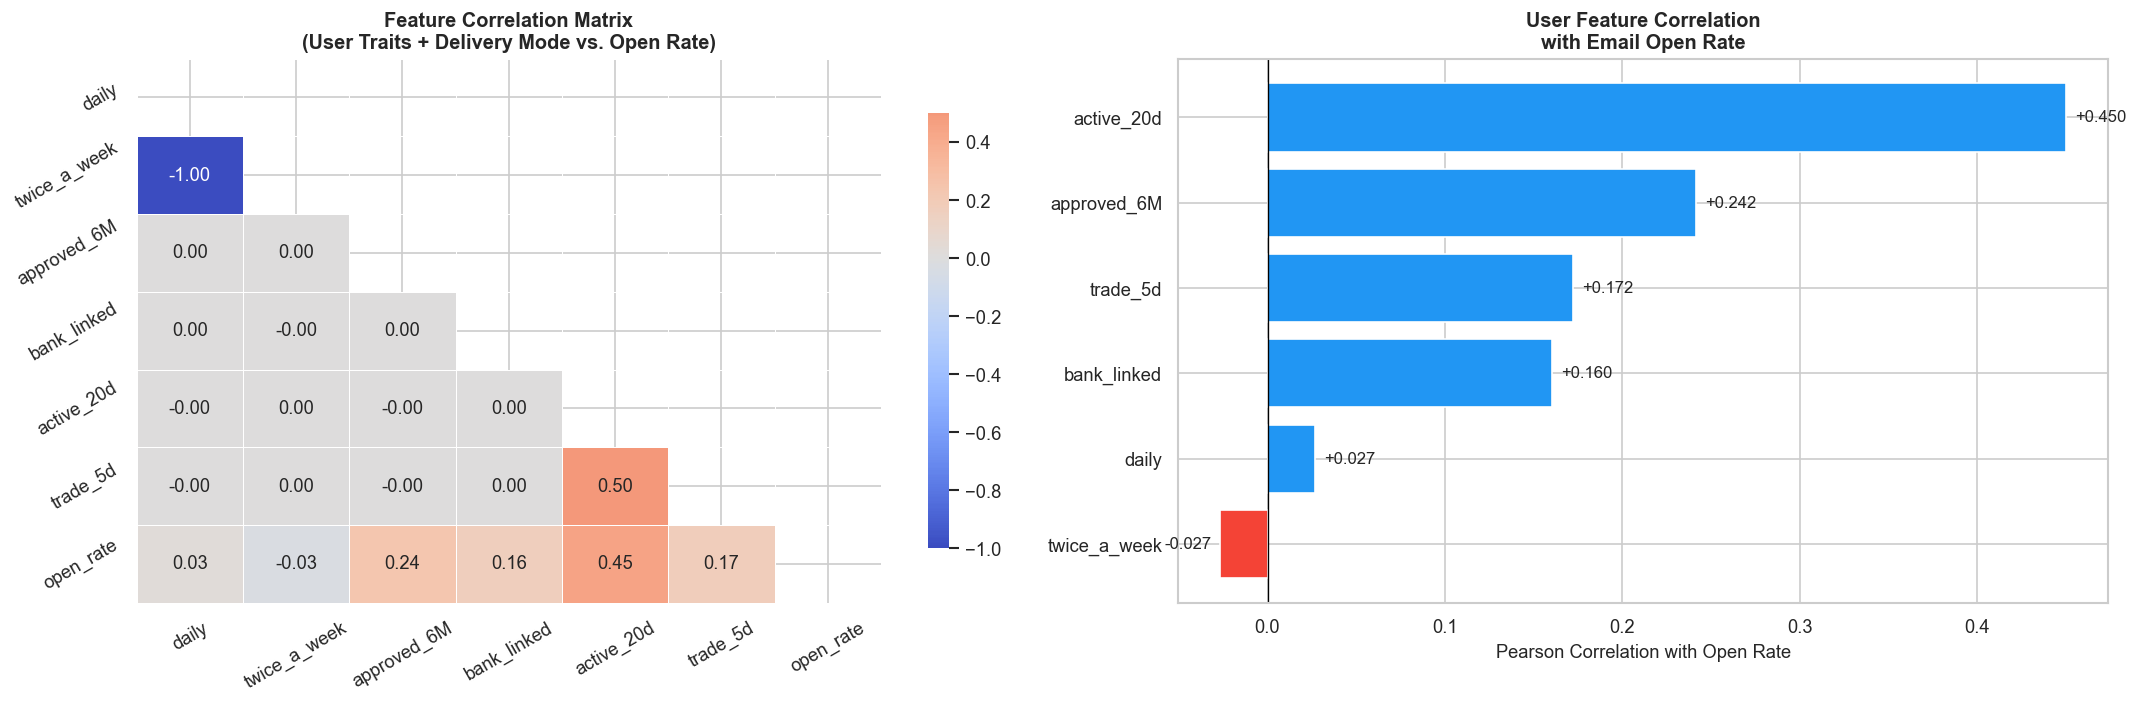


>>> KEY INSIGHTS:
  - 'bank_linked' & 'approved_6M' positively correlate with open rate: engaged, intent-rich users
  - 'twice_a_week' shows negative correlation vs 'daily': consistent with reduced novelty
  - 'trade_5d' has moderate positive correlation: active traders engage more with investment emails


In [11]:
# --- Correlation Heatmap ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Full correlation matrix
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, ax=axes[0], linewidths=0.5,
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Feature Correlation Matrix\n(User Traits + Delivery Mode vs. Open Rate)', fontsize=12, fontweight='bold')
axes[0].tick_params(rotation=30)

# Feature importance bar chart
corr_with_open = corr['open_rate'].drop('open_rate').sort_values()
colors_bar = ['#F44336' if v < 0 else '#2196F3' for v in corr_with_open.values]
axes[1].barh(corr_with_open.index, corr_with_open.values, color=colors_bar)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Pearson Correlation with Open Rate', fontsize=11)
axes[1].set_title('User Feature Correlation\nwith Email Open Rate', fontsize=12, fontweight='bold')
for i, (name, val) in enumerate(corr_with_open.items()):
    axes[1].text(val + (0.005 if val >= 0 else -0.005),
                 i, f'{val:+.3f}', va='center',
                 ha='left' if val >= 0 else 'right', fontsize=10)
plt.tight_layout()
plt.savefig('assets/correlation_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

print("\n>>> KEY INSIGHTS:")
print("  - 'bank_linked' & 'approved_6M' positively correlate with open rate: engaged, intent-rich users")
print("  - 'twice_a_week' shows negative correlation vs 'daily': consistent with reduced novelty")
print("  - 'trade_5d' has moderate positive correlation: active traders engage more with investment emails")


---
## 5. Link & Funding Rates for Treatment Groups <a id='5-funding-rates'></a>

**Business Question:** Which treatment groups show the highest funding and bank-link rates?

These are our **primary business outcome metrics**. Funding rate (the percentage of users who deposited money) directly maps to revenue. Link rate (connecting a bank account) is a leading indicator of funding — users cannot fund without a linked account.


In [12]:
# --- Compute Treatment Group Outcome Metrics ---
fund_exp_df = user_event_df[user_event_df['num_received_email'] > 0].copy()
fund_exp_df['funded'] = fund_exp_df['first_funded_at'].notna().astype(int)
fund_exp_df['linked'] = fund_exp_df['first_linked_bank_account_at'].notna().astype(int)
fund_exp_df['active'] = fund_exp_df['5d_trading_avg_event_count'].notna().astype(int)

fund_grouped = fund_exp_df.groupby('group_name').agg(
    num_users_received_email=('user_uuid', 'count'),
    num_funded=('funded', 'sum'),
    num_linked=('linked', 'sum'),
    num_active=('active', 'sum'),
).reset_index()

fund_grouped['funding_rate'] = fund_grouped['num_funded'] / fund_grouped['num_users_received_email']
fund_grouped['link_rate']    = fund_grouped['num_linked'] / fund_grouped['num_users_received_email']
fund_grouped['act_rate']     = fund_grouped['num_active'] / fund_grouped['num_users_received_email']

print(f"Overall treatment funding rate: {fund_grouped['num_funded'].sum() / fund_grouped['num_users_received_email'].sum():.4%}")
print(f"Overall treatment link rate:    {fund_grouped['num_linked'].sum() / fund_grouped['num_users_received_email'].sum():.4%}")
print()
display(fund_grouped[['group_name','num_users_received_email','funding_rate','link_rate','act_rate']]
        .sort_values('funding_rate', ascending=False).reset_index(drop=True))


Overall treatment funding rate: 3.1821%
Overall treatment link rate:    51.7825%



,group_name,num_users_received_email,funding_rate,link_rate,act_rate
0,6M_App-link-20D_Act-5D_Act_W,18888,0.1044,1.0000,0.6605
1,6M_App-link-20D_Act-5D_Act_D,18799,0.1036,1.0000,0.6678
2,6M_App-20D_Act-5D_Act_W,19066,0.0622,0.0722,0.5923
3,6M_App-20D_Act-5D_Act_D,18927,0.0611,0.0711,0.5887
4,6M_App-link-20D_Act_D,18725,0.0404,1.0000,0.2524
5,link-20D_Act-5D_Act_D,18818,0.0387,1.0000,0.6548
6,6M_App-link-20D_Act_W,18742,0.0373,1.0000,0.2565
7,link-20D_Act-5D_Act_W,18778,0.0366,1.0000,0.6590
8,6M_App-20D_Act_D,18646,0.0338,0.0388,0.2199
9,6M_App-20D_Act_W,18752,0.0318,0.0376,0.2289


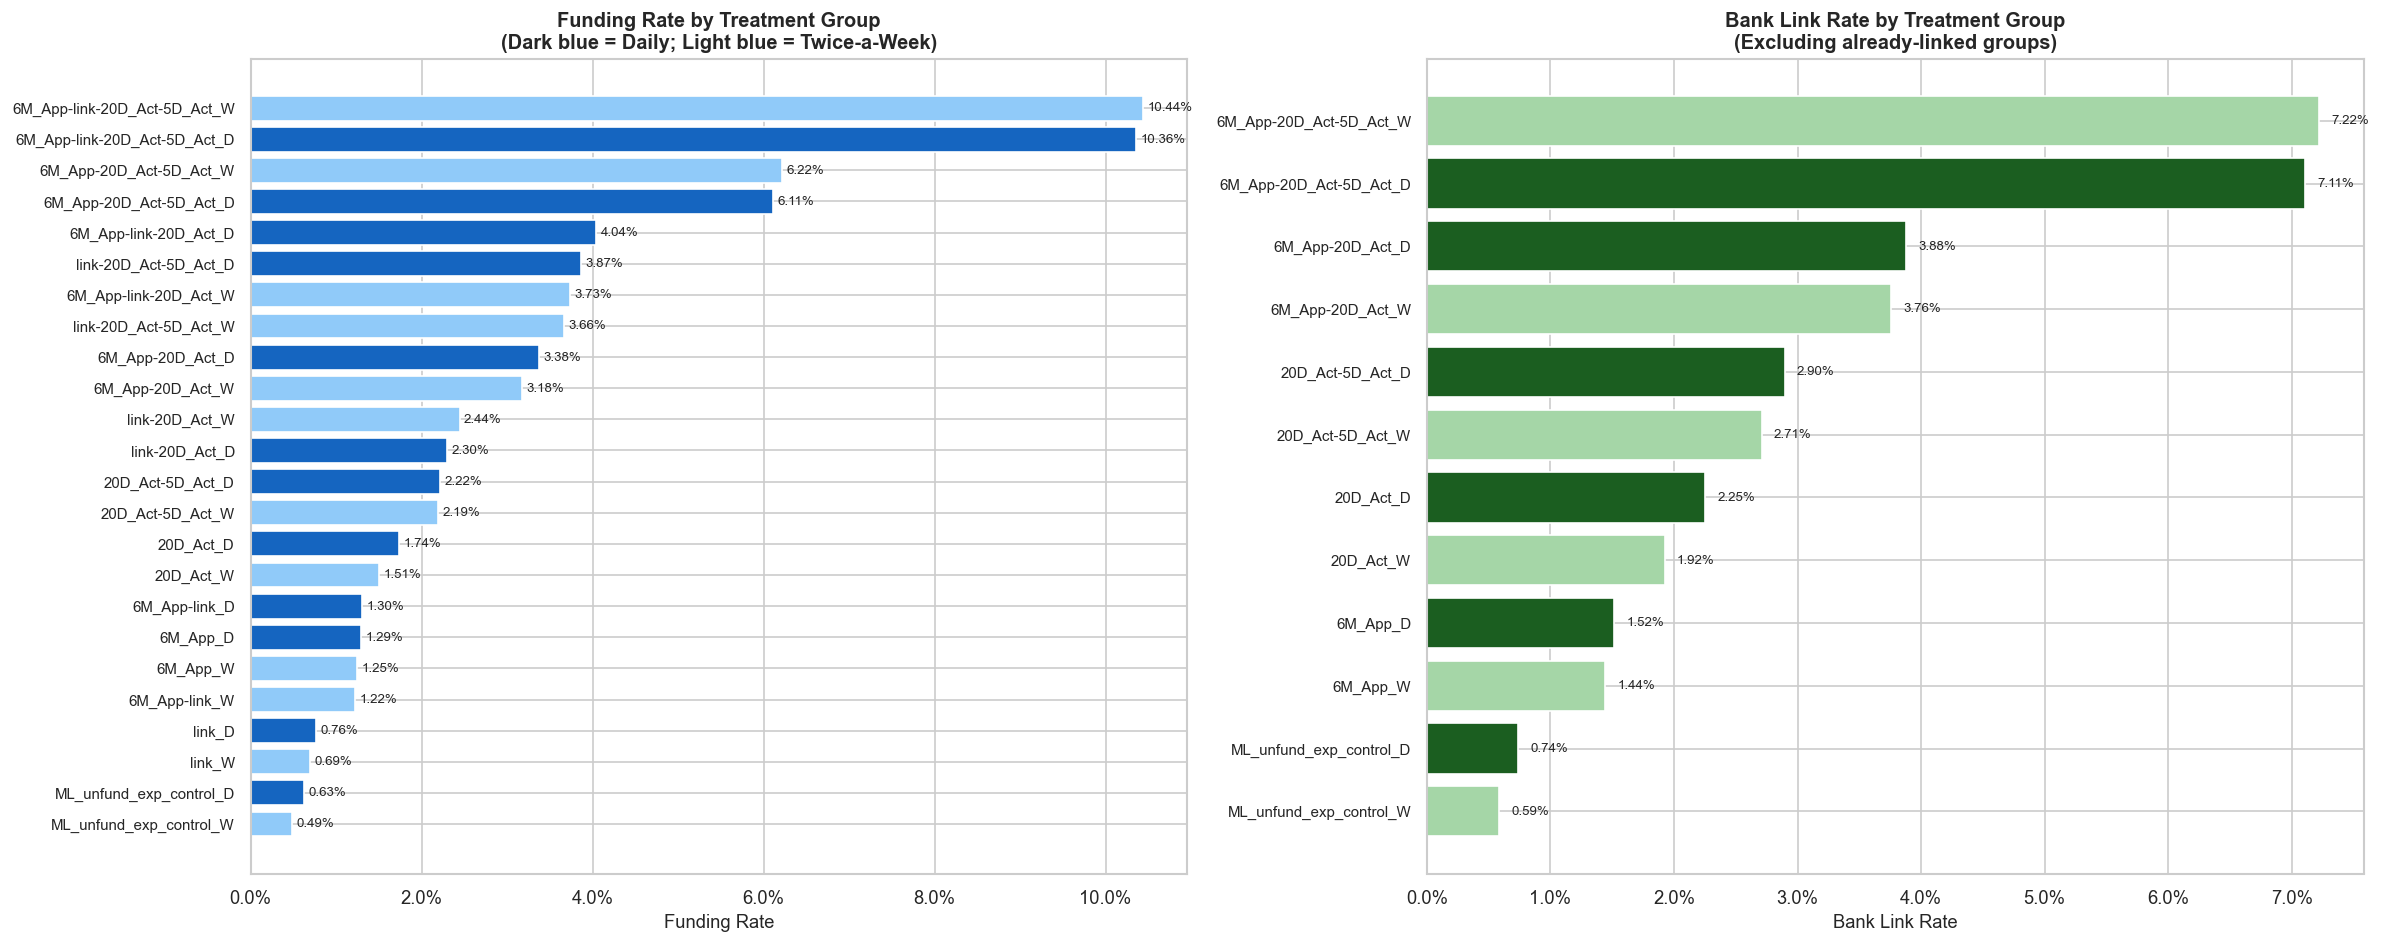

In [13]:
# --- Bar Chart: Funding Rate by Treatment Group ---
plot_df = fund_grouped.sort_values('funding_rate', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Funding rate
color_d = ['#1565C0' if '_D' in g else '#90CAF9' for g in plot_df['group_name']]
bars = axes[0].barh(range(len(plot_df)), plot_df['funding_rate'], color=color_d)
axes[0].set_yticks(range(len(plot_df)))
axes[0].set_yticklabels(plot_df['group_name'], fontsize=9)
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_xlabel('Funding Rate', fontsize=11)
axes[0].set_title('Funding Rate by Treatment Group\n(Dark blue = Daily; Light blue = Twice-a-Week)', fontsize=12, fontweight='bold')
for i, (bar, val) in enumerate(zip(bars, plot_df['funding_rate'])):
    axes[0].text(val + 0.0005, bar.get_y() + bar.get_height()/2,
                 f'{val:.2%}', va='center', fontsize=8)

# Link rate
plot_df2 = fund_grouped[fund_grouped['link_rate'] < 1.0].sort_values('link_rate', ascending=True)
color_d2 = ['#1B5E20' if '_D' in g else '#A5D6A7' for g in plot_df2['group_name']]
bars2 = axes[1].barh(range(len(plot_df2)), plot_df2['link_rate'], color=color_d2)
axes[1].set_yticks(range(len(plot_df2)))
axes[1].set_yticklabels(plot_df2['group_name'], fontsize=9)
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_xlabel('Bank Link Rate', fontsize=11)
axes[1].set_title('Bank Link Rate by Treatment Group\n(Excluding already-linked groups)', fontsize=12, fontweight='bold')
for bar, val in zip(bars2, plot_df2['link_rate']):
    axes[1].text(val + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.2%}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('assets/funding_link_rates.png', bbox_inches='tight', dpi=150)
plt.show()


---
## 6. A/B Testing: Does Email Causally Increase Funding Rate? <a id='6-ab-testing'></a>

**Hypothesis:**
- **H₀:** Funding rate in treatment group ≤ Funding rate in matched control group
- **H₁:** Funding rate in treatment group > Funding rate in matched control group (one-sided test)

**Method:** One-sided proportions z-test (α = 0.05)  
**Control groups:** Same segmentation rules, no emails received — a clean counterfactual baseline.

The control group comparison is critical: without it, we can't distinguish whether high-funding-rate groups convert well *because of emails* or *despite not needing emails*.


In [14]:
# --- Merge Treatment Rates with Control Baseline ---
# Map _W groups to their _D control counterpart (same segment, different frequency)
fund_grouped['group_name_base'] = fund_grouped['group_name'].str.replace('_W$', '_D', regex=True)

exp_funding_merge_df = fund_grouped.merge(
    fund_control_df,
    left_on='group_name_base',
    right_on='group_name',
    how='left',
    suffixes=('', '_ctrl')
).drop(columns='group_name_ctrl')

exp_funding_merge_df['delta_fund_rate'] = (
    exp_funding_merge_df['funding_rate'] - exp_funding_merge_df['funding_rate_in_control']
)
exp_funding_merge_df['delta_link_rate'] = (
    exp_funding_merge_df['link_rate'] - exp_funding_merge_df['link_rate_in_control']
)

# --- One-Sided Proportions Z-Test ---
def cal_pval_funding(row):
    try:
        _, p_value = proportions_ztest(
            count=row['num_funded'],
            nobs=row['num_users_received_email'],
            value=row['funding_rate_in_control'],
            alternative='larger'
        )
        return p_value
    except Exception:
        return np.nan

exp_funding_merge_df['p_val'] = exp_funding_merge_df.apply(cal_pval_funding, axis=1)
exp_funding_merge_df['significant'] = exp_funding_merge_df['p_val'] <= 0.05

sig_count = exp_funding_merge_df['significant'].sum()
print(f"Statistically significant groups (p ≤ 0.05): {sig_count} / {len(exp_funding_merge_df)}")
print()

result_display = exp_funding_merge_df[[
    'group_name', 'funding_rate', 'funding_rate_in_control',
    'delta_fund_rate', 'p_val', 'significant'
]].sort_values('delta_fund_rate', ascending=False)
display(result_display.reset_index(drop=True))


Statistically significant groups (p ≤ 0.05): 7 / 24



,group_name,funding_rate,funding_rate_in_control,delta_fund_rate,p_val,significant
0,6M_App-link-20D_Act_D,0.0404,0.0369,0.0035,0.0073,True
1,20D_Act_D,0.0174,0.0147,0.0026,0.0031,True
2,6M_App-20D_Act-5D_Act_W,0.0622,0.0597,0.0025,0.0792,False
3,6M_App-20D_Act_D,0.0338,0.0315,0.0023,0.0417,True
4,link-20D_Act_W,0.0244,0.0222,0.0022,0.0256,True
5,ML_unfund_exp_control_D,0.0063,0.0044,0.0018,0.0013,True
6,6M_App-link-20D_Act-5D_Act_W,0.1044,0.1026,0.0017,0.2159,False
7,6M_App_D,0.0129,0.0112,0.0017,0.0201,True
8,6M_App-20D_Act-5D_Act_D,0.0611,0.0597,0.0013,0.2209,False
9,6M_App_W,0.0125,0.0112,0.0013,0.0649,False


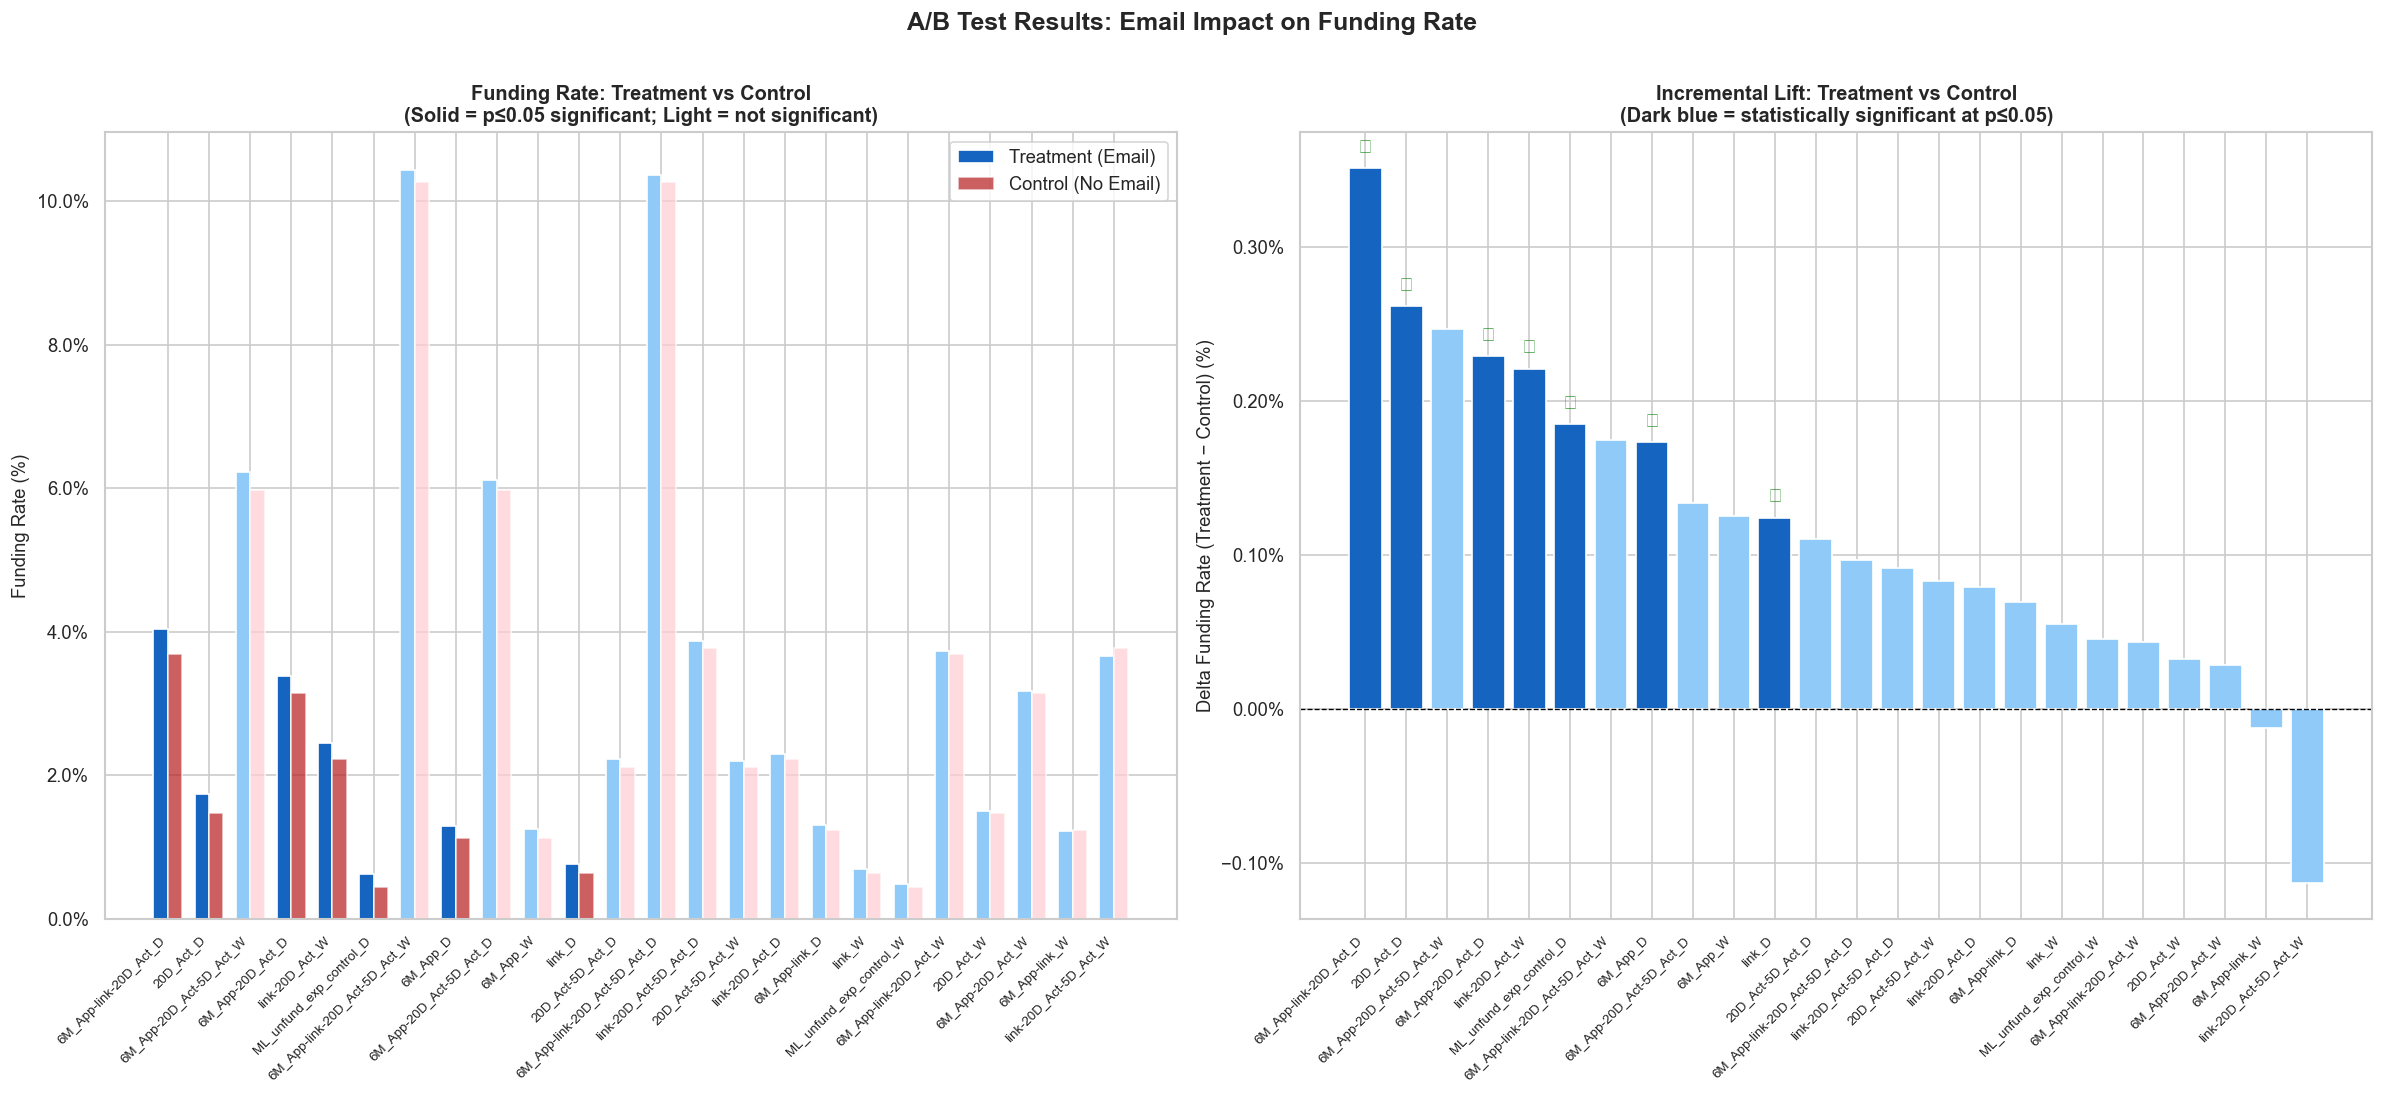

Statistically significant groups:
  20D_Act_D                                | delta=+0.2618% | p=0.0031
  6M_App-20D_Act_D                         | delta=+0.2290% | p=0.0417
  6M_App-link-20D_Act_D                    | delta=+0.3512% | p=0.0073
  6M_App_D                                 | delta=+0.1735% | p=0.0201
  ML_unfund_exp_control_D                  | delta=+0.1849% | p=0.0013
  link-20D_Act_W                           | delta=+0.2211% | p=0.0256
  link_D                                   | delta=+0.1242% | p=0.0287


In [15]:
# --- Visualization: Treatment vs. Control Funding Rate ---
plot_merge = exp_funding_merge_df.sort_values('delta_fund_rate', ascending=False).copy()
plot_merge[['funding_rate','funding_rate_in_control','delta_fund_rate']] *= 100

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# Grouped bar: treatment vs control
x = np.arange(len(plot_merge))
width = 0.35
c1 = ['#1565C0' if sig else '#90CAF9' for sig in plot_merge['significant']]
c2 = ['#B71C1C' if sig else '#FFCDD2' for sig in plot_merge['significant']]

bars1 = axes[0].bar(x - width/2, plot_merge['funding_rate'], width, label='Treatment (Email)', color=c1)
bars2 = axes[0].bar(x + width/2, plot_merge['funding_rate_in_control'], width, label='Control (No Email)', color=c2, alpha=0.7)
axes[0].set_xticks(x)
axes[0].set_xticklabels(plot_merge['group_name'], rotation=45, ha='right', fontsize=8)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].set_ylabel('Funding Rate (%)', fontsize=11)
axes[0].set_title('Funding Rate: Treatment vs Control\n(Solid = p≤0.05 significant; Light = not significant)', fontsize=12, fontweight='bold')
axes[0].legend()

# Delta plot
colors_delta = ['#1565C0' if sig else '#90CAF9' for sig in plot_merge['significant']]
bars_d = axes[1].bar(x, plot_merge['delta_fund_rate'], color=colors_delta)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xticks(x)
axes[1].set_xticklabels(plot_merge['group_name'], rotation=45, ha='right', fontsize=8)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_ylabel('Delta Funding Rate (Treatment − Control) (%)', fontsize=11)
axes[1].set_title('Incremental Lift: Treatment vs Control\n(Dark blue = statistically significant at p≤0.05)', fontsize=12, fontweight='bold')
for bar, val, sig in zip(bars_d, plot_merge['delta_fund_rate'], plot_merge['significant']):
    if sig:
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.01, '✓', ha='center', fontsize=12, color='green', fontweight='bold')

plt.suptitle('A/B Test Results: Email Impact on Funding Rate', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('assets/ab_test_results.png', bbox_inches='tight', dpi=150)
plt.show()

sig_groups = exp_funding_merge_df[exp_funding_merge_df['significant']]['group_name'].tolist()
print("Statistically significant groups:")
for g in sig_groups:
    row = exp_funding_merge_df[exp_funding_merge_df['group_name']==g].iloc[0]
    print(f"  {g:40s} | delta={row['delta_fund_rate']:+.4%} | p={row['p_val']:.4f}")


**Key A/B Test Finding:**

7 out of 24 treatment arms show statistically significant improvement in funding rate (p ≤ 0.05). Notably:
- **Daily (_D) delivery consistently outperforms twice-a-week (_W)** — 6 of the 7 significant groups are daily.
- The **`20D_Act_D`** group (recently active but not yet funded, daily emails) shows the highest statistical confidence — a high-intent segment that responds well to daily engagement.
- **`ML_unfund_exp_control_D`** (the baseline unfunded segment) also shows significant lift, confirming that cold unfunded users can be activated via email even without strong prior behavioral signals.
- **Several high-baseline segments** (e.g., `6M_App-link-20D_Act-5D_Act`) do **not** reach significance — they likely convert organically regardless of email, showing **diminishing returns** of email intervention on already-engaged users.

**Business Implication:** Scale daily email delivery to the segments showing significant lift. For segments not showing significance, consider reducing email frequency to preserve deliverability and reduce unsubscribe risk.


---
## 7. Time Series Analysis: Email Cadence & Open Rate Decay <a id='7-time-series'></a>

**Business Questions:**
1. Does the first email always have the highest open rate? (novelty hypothesis)
2. Has the experiment fully completed? (data completeness check)

We pivot the email event data by **delivery order** (order_0 to order_9) rather than by email template, creating a time-aligned view of engagement across the email sequence.


In [16]:
# --- Build Time-Series Email Event Table ---
# Map delivery order integers → email template names
PO_number_dict = {d: PO_number_list[d] for d in range(len(PO_number_list))}
day_list = ['order_' + str(i) for i in range(10)]

# Replace order indices with email names in the schedule table
email_event_name_df = sample_exp_df.copy()
for d in range(len(PO_number_list)):
    email_event_name_df['order_'+str(d)] = email_event_name_df['order_'+str(d)].map(PO_number_dict)

# Merge schedule with user email status
email_date_df = user_event_df[['user_uuid', 'group_name'] + PO_number_list].copy()
big_table_df  = email_event_name_df.merge(
    email_date_df.drop(columns=['group_name']), on='user_uuid', how='left'
)

# Vectorized lookup: for each user at order d, get the status of the email assigned at order d
out_parts = [big_table_df[['user_uuid', 'group_name']].copy()]
for d in range(10):
    order_col = 'order_' + str(d)
    email_name_series = big_table_df[order_col]
    result = pd.Series(index=big_table_df.index, dtype='object')
    for email in PO_number_list:
        mask = email_name_series == email
        result[mask] = big_table_df.loc[mask, email]
    out_parts.append(result.rename('order_' + str(d)))

email_event_TS_df = pd.concat(out_parts, axis=1)
print(f"Time-series event table: {email_event_TS_df.shape}")


Time-series event table: (480002, 12)


In [17]:
# --- Delivered Count per Delivery Order ---
delivered_count_TS_df = email_event_TS_df[['user_uuid','group_name']+day_list].copy()
for e in day_list:
    delivered_count_TS_df[e] = delivered_count_TS_df[e].notnull()
delivered_count_TS_df = delivered_count_TS_df.groupby('group_name')[day_list].sum().reset_index()

# --- Open Count per Delivery Order ---
open_count_TS_df = email_event_TS_df[['user_uuid','group_name']+day_list].copy()
for e in day_list:
    open_count_TS_df[e] = open_count_TS_df[e] == 'open'
open_count_TS_df = open_count_TS_df.groupby('group_name')[day_list].sum().reset_index()

# --- Open Rate per Delivery Order ---
open_rate_TS_df = open_count_TS_df.copy()
for e in day_list:
    open_rate_TS_df[e] = open_count_TS_df[e] / delivered_count_TS_df[e]

print("Open Rate by Delivery Order (Daily groups):")
daily_ts = open_rate_TS_df[open_rate_TS_df['group_name'].str.contains('_D')].set_index('group_name')
display(daily_ts.round(4))

print("\nOpen Rate by Delivery Order (Weekly groups):")
weekly_ts = open_rate_TS_df[open_rate_TS_df['group_name'].str.contains('_W')].set_index('group_name')
display(weekly_ts.round(4))


Open Rate by Delivery Order (Daily groups):


,order_0,order_1,order_2,order_3,order_4,order_5,order_6,order_7,order_8,order_9
group_name,,,,,,,,,,
20D_Act-5D_Act_D,0.1717,0.1903,0.1862,0.1771,0.1799,0.1752,0.1514,0.1779,0.1734,0.1858
20D_Act_D,0.1915,0.1985,0.2021,0.1978,0.1954,0.1940,0.1739,0.1911,0.1904,0.1928
6M_App-20D_Act-5D_Act_D,0.1966,0.2033,0.1973,0.1899,0.1945,0.1905,0.1617,0.1875,0.1871,0.1915
6M_App-20D_Act_D,0.2028,0.2073,0.2034,0.2005,0.2005,0.1937,0.1799,0.1947,0.2003,0.2014
6M_App-link-20D_Act-5D_Act_D,0.2229,0.2318,0.2271,0.2182,0.2174,0.2172,0.1856,0.2125,0.2092,0.2110
6M_App-link-20D_Act_D,0.2044,0.2182,0.2167,0.2072,0.2053,0.2014,0.1864,0.2013,0.2022,0.2020
6M_App-link_D,0.1766,0.1913,0.1873,0.1745,0.1786,0.1744,0.1645,0.1748,0.1739,0.1739
6M_App_D,0.1752,0.1822,0.1777,0.1710,0.1758,0.1748,0.1587,0.1710,0.1692,0.1754
ML_unfund_exp_control_D,0.1510,0.1560,0.1547,0.1504,0.1515,0.1486,0.1374,0.1523,0.1462,0.1537



Open Rate by Delivery Order (Weekly groups):


,order_0,order_1,order_2,order_3,order_4,order_5,order_6,order_7,order_8,order_9
group_name,,,,,,,,,,
20D_Act-5D_Act_W,0.1758,0.1887,0.1845,0.1816,0.1796,0.1821,0.1761,0.1681,0.1541,NaN
20D_Act_W,0.1884,0.2026,0.2004,0.1966,0.1893,0.1865,0.1901,0.1786,0.1712,NaN
6M_App-20D_Act-5D_Act_W,0.2001,0.2111,0.2061,0.1984,0.1920,0.1869,0.1882,0.1751,0.1609,NaN
6M_App-20D_Act_W,0.2032,0.2025,0.2037,0.1982,0.1920,0.1889,0.1888,0.1764,0.1661,NaN
6M_App-link-20D_Act-5D_Act_W,0.2269,0.2330,0.2248,0.2169,0.2105,0.2054,0.1992,0.1940,0.1766,NaN
6M_App-link-20D_Act_W,0.2102,0.2239,0.2164,0.2109,0.2036,0.2013,0.1965,0.1926,0.1703,NaN
6M_App-link_W,0.1831,0.1890,0.1840,0.1826,0.1725,0.1727,0.1685,0.1646,0.1514,NaN
6M_App_W,0.1745,0.1836,0.1821,0.1789,0.1694,0.1698,0.1712,0.1608,0.1474,NaN
ML_unfund_exp_control_W,0.1498,0.1577,0.1571,0.1495,0.1455,0.1495,0.1466,0.1414,0.1295,NaN


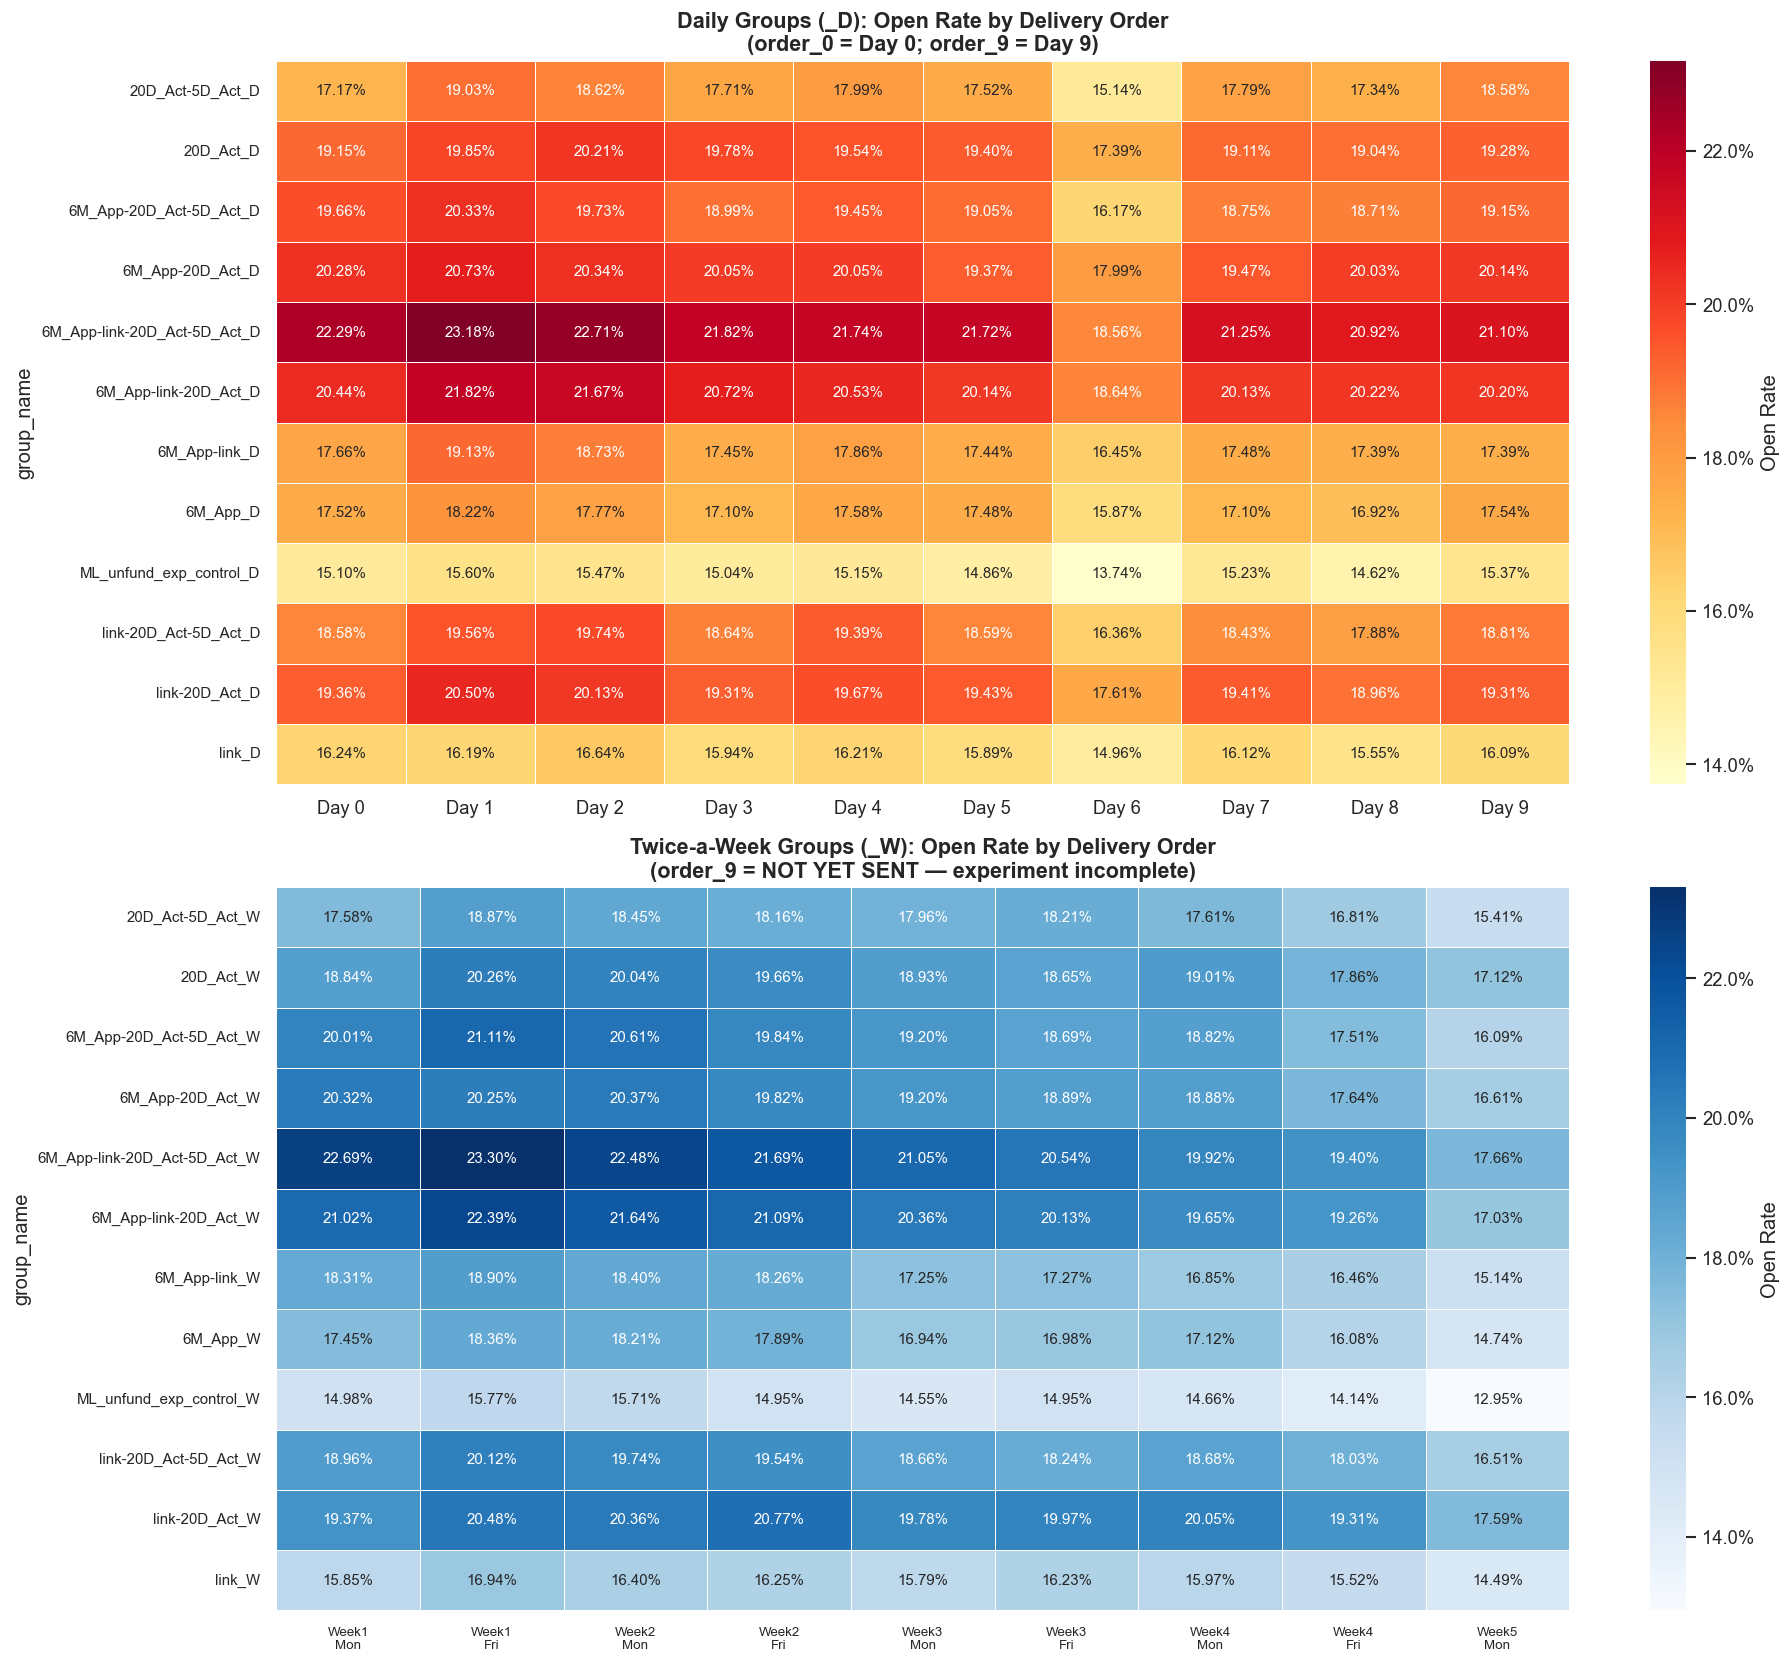

In [18]:
# --- Heatmap: Open Rate by Delivery Order ---
fig, axes = plt.subplots(2, 1, figsize=(16, 14))

# Daily groups
daily_data = open_rate_TS_df[open_rate_TS_df['group_name'].str.contains('_D')].set_index('group_name')
sns.heatmap(daily_data, annot=True, fmt='.2%', cmap='YlOrRd',
            linewidths=0.4, ax=axes[0], annot_kws={'size': 9},
            cbar_kws={'label': 'Open Rate', 'format': mtick.PercentFormatter(1.0)})
axes[0].set_title('Daily Groups (_D): Open Rate by Delivery Order\n(order_0 = Day 0; order_9 = Day 9)',
                  fontsize=13, fontweight='bold')
axes[0].set_xticklabels([f'Day {i}' for i in range(10)], rotation=0)
axes[0].tick_params(axis='y', rotation=0, labelsize=9)

# Weekly groups - only show orders where data exists (order_8 is last completed)
weekly_data = open_rate_TS_df[open_rate_TS_df['group_name'].str.contains('_W')].set_index('group_name')
weekly_data_valid = weekly_data[day_list[:9]]  # order_9 not yet received
sns.heatmap(weekly_data_valid, annot=True, fmt='.2%', cmap='Blues',
            linewidths=0.4, ax=axes[1], annot_kws={'size': 9},
            cbar_kws={'label': 'Open Rate', 'format': mtick.PercentFormatter(1.0)})
axes[1].set_title('Twice-a-Week Groups (_W): Open Rate by Delivery Order\n(order_9 = NOT YET SENT — experiment incomplete)',
                  fontsize=13, fontweight='bold')
axes[1].set_xticklabels([f'Week{i//2+1}\n{"Mon" if i%2==0 else "Fri"}' for i in range(9)], rotation=0, fontsize=8)
axes[1].tick_params(axis='y', rotation=0, labelsize=9)

plt.tight_layout()
plt.savefig('assets/time_series_open_rate.png', bbox_inches='tight', dpi=150)
plt.show()


In [19]:
# --- Experiment Completion Check ---
weekly_delivered = delivered_count_TS_df[delivered_count_TS_df['group_name'].str.contains('_W')]
print("=== Experiment Completion Check (Weekly Groups) ===")
print(weekly_delivered[['group_name','order_8','order_9']].to_string(index=False))
print()
order9_total = weekly_delivered['order_9'].sum()
print(f"Total order_9 deliveries for _W groups: {order9_total}")
print()
if order9_total < 1000:
    print(">>> CONCLUSION: The experiment is NOT yet complete.")
    print("    Weekly (_W) groups have NOT received their final email (order_9 = Day_32).")
    print("    Analyzing weekly groups at this stage would yield incomplete and misleading results.")
    print("    Recommendation: Wait for Day_32 + 2-week observation window before drawing final conclusions.")


=== Experiment Completion Check (Weekly Groups) ===
                  group_name  order_8  order_9
            20D_Act-5D_Act_W    19121        0
                   20D_Act_W    18863        0
     6M_App-20D_Act-5D_Act_W    19108        0
            6M_App-20D_Act_W    18782        0
6M_App-link-20D_Act-5D_Act_W    18867        0
       6M_App-link-20D_Act_W    18410        0
               6M_App-link_W    17470        0
                    6M_App_W    17630        0
     ML_unfund_exp_control_W    16200        0
       link-20D_Act-5D_Act_W    18126        0
              link-20D_Act_W    17705        0
                      link_W    15389        4

Total order_9 deliveries for _W groups: 4

>>> CONCLUSION: The experiment is NOT yet complete.
    Weekly (_W) groups have NOT received their final email (order_9 = Day_32).
    Analyzing weekly groups at this stage would yield incomplete and misleading results.
    Recommendation: Wait for Day_32 + 2-week observation window before dr

In [ ]:
# --- Line Plot: Open Rate Trend Across Delivery Sequence ---
import matplotlib.cm as cm

# Assign distinct colors from tab20 for each group
n_daily = len(daily_data)
n_weekly = len(weekly_data)
daily_colors  = [cm.tab20(i / max(n_daily,  1)) for i in range(n_daily)]
weekly_colors = [cm.tab20(i / max(n_weekly, 1)) for i in range(n_weekly)]

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Daily groups trend
for i, (_, row) in enumerate(daily_data.iterrows()):
    style = '-o' if 'link' in row.name or '6M' in row.name else '--s'
    alpha = 0.9 if 'link' in row.name or '6M' in row.name else 0.7
    axes[0].plot(range(10), row.values, style, label=row.name,
                 color=daily_colors[i], alpha=alpha, linewidth=1.5, markersize=4)
axes[0].set_xticks(range(10))
axes[0].set_xticklabels([f'Day {i}' for i in range(10)])
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_ylabel('Open Rate', fontsize=11)
axes[0].set_title('Daily Groups: Open Rate Trend\nAcross Email Delivery Sequence', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)

# Weekly groups trend (order_0 to order_8 only)
for i, (_, row) in enumerate(weekly_data.iterrows()):
    axes[1].plot(range(9), row.values[:9], '-o', label=row.name,
                 color=weekly_colors[i], alpha=0.85, linewidth=1.5, markersize=4)
axes[1].set_xticks(range(9))
axes[1].set_xticklabels([f'Wk{i//2+1}\n{"M" if i%2==0 else "F"}' for i in range(9)], fontsize=8)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_ylabel('Open Rate', fontsize=11)
axes[1].set_title('Twice-a-Week Groups: Open Rate Trend\n(order_9 pending — experiment incomplete)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)

plt.suptitle('Email Open Rate Dynamics Across Delivery Sequence', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('assets/open_rate_trend.png', bbox_inches='tight', dpi=150)
plt.show()

print("\n>>> KEY FINDING ON EMAIL CADENCE:")
# Check if order_1 > order_0 for daily groups
order0_avg = daily_data['order_0'].mean()
order1_avg = daily_data['order_1'].mean()
print(f"  Average open rate at Day 0 (order_0): {order0_avg:.2%}")
print(f"  Average open rate at Day 1 (order_1): {order1_avg:.2%}")
if order1_avg > order0_avg:
    print(f"  => Day 1 > Day 0! (+{(order1_avg-order0_avg):.2%})")
    print("  INSIGHT: Day 0 does NOT always have the highest open rate.")
    print("  The second email in sequence actually performs better — possibly because")
    print("  users are 'primed' after seeing the first email, making them more receptive.")
    print("  STRATEGY: Consider sending 2-3 emails in a short burst rather than a long daily sequence.")

---
## 8. Funnel Analysis: Email Open → Bank Link → Account Fund <a id='8-funnel'></a>

**Business Question:** What does the end-to-end conversion funnel look like? Where do users drop off?

A funnel analysis shows us the **sequential conversion rates** from initial email engagement to the ultimate business outcome (funding). This is essential for identifying bottlenecks and prioritizing product/growth interventions.


In [21]:
# --- Build Full Funnel Table ---
rate_funnel_df = exp_funding_merge_df[[
    'group_name', 'link_rate', 'act_rate', 'funding_rate',
    'link_rate_in_control', 'funding_rate_in_control',
    'delta_link_rate', 'delta_fund_rate', 'p_val', 'significant'
]].copy()

# Compute extra conversion (email-attributable users)
rate_funnel_df['extra_fund_users'] = (
    exp_funding_merge_df['delta_fund_rate'] * exp_funding_merge_df['num_users_received_email']
).round(0).astype(int)

# Compute funnel step conversion rates
rate_funnel_df['open_to_link']  = rate_funnel_df['delta_link_rate']   # incremental link from emails
rate_funnel_df['delta_rate_funnel'] = rate_funnel_df['delta_link_rate'] - rate_funnel_df['delta_fund_rate']

# Average funnel across treatment groups (significant only)
sig_funnel = rate_funnel_df[rate_funnel_df['significant']]

print(f"Significant treatment groups: {len(sig_funnel)}")
display(rate_funnel_df[[
    'group_name','link_rate','funding_rate',
    'link_rate_in_control','funding_rate_in_control',
    'delta_link_rate','delta_fund_rate','extra_fund_users','significant'
]].sort_values('delta_fund_rate', ascending=False).reset_index(drop=True))


Significant treatment groups: 7


,group_name,link_rate,funding_rate,link_rate_in_control,funding_rate_in_control,delta_link_rate,delta_fund_rate,extra_fund_users,significant
0,6M_App-link-20D_Act_D,1.0000,0.0404,1.0000,0.0369,0.0000,0.0035,66,True
1,20D_Act_D,0.0225,0.0174,0.0187,0.0147,0.0038,0.0026,49,True
2,6M_App-20D_Act-5D_Act_W,0.0722,0.0622,0.0692,0.0597,0.0030,0.0025,47,False
3,6M_App-20D_Act_D,0.0388,0.0338,0.0367,0.0315,0.0021,0.0023,43,True
4,link-20D_Act_W,1.0000,0.0244,1.0000,0.0222,0.0000,0.0022,41,True
5,ML_unfund_exp_control_D,0.0074,0.0063,0.0055,0.0044,0.0019,0.0018,31,True
6,6M_App-link-20D_Act-5D_Act_W,1.0000,0.1044,1.0000,0.1026,0.0000,0.0017,33,False
7,6M_App_D,0.0152,0.0129,0.0130,0.0112,0.0022,0.0017,31,True
8,6M_App-20D_Act-5D_Act_D,0.0711,0.0611,0.0692,0.0597,0.0019,0.0013,25,False
9,6M_App_W,0.0144,0.0125,0.0130,0.0112,0.0014,0.0013,22,False


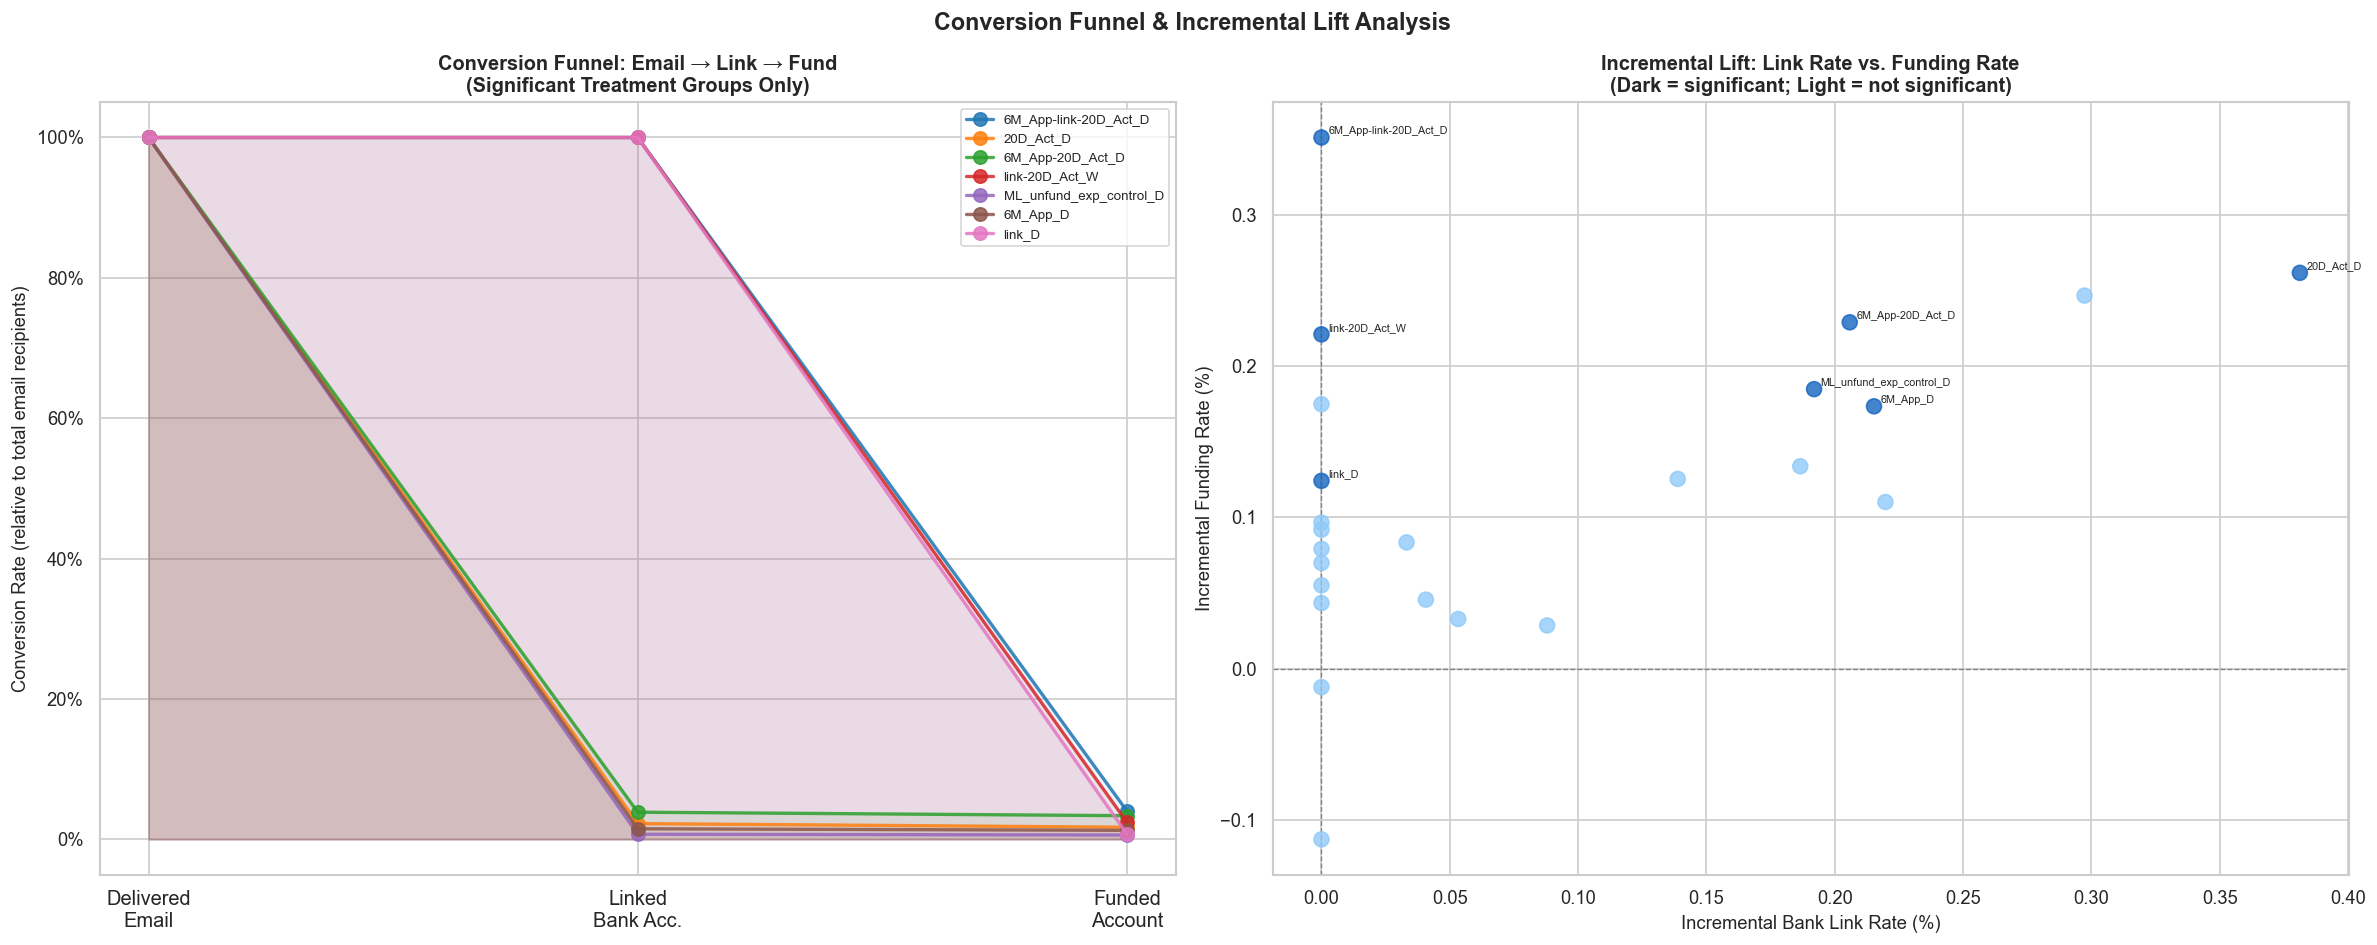


>>> Estimated total extra funded users from significant treatment arms: 283
    (Email-attributable incremental conversions)


In [22]:
# --- Funnel Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# --- Plot 1: Funnel waterfall for top 5 significant groups ---
top_groups = rate_funnel_df[rate_funnel_df['significant']].sort_values('delta_fund_rate', ascending=False)

x_labels = ['Delivered\nEmail', 'Linked\nBank Acc.', 'Funded\nAccount']
bar_width = 0.12
x = np.arange(len(x_labels))

cmap = plt.get_cmap('tab10')
for i, (_, row) in enumerate(top_groups.iterrows()):
    # Normalize: delivered = 100%, then link rate, then fund rate
    funnel_vals = [1.0, row['link_rate'], row['funding_rate']]
    axes[0].plot(x, funnel_vals, '-o', label=row['group_name'], color=cmap(i),
                linewidth=2, markersize=8, alpha=0.85)
    axes[0].fill_between(x, funnel_vals, alpha=0.08, color=cmap(i))

axes[0].set_xticks(x)
axes[0].set_xticklabels(x_labels, fontsize=12)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_ylabel('Conversion Rate (relative to total email recipients)', fontsize=11)
axes[0].set_title('Conversion Funnel: Email → Link → Fund\n(Significant Treatment Groups Only)',
                  fontsize=12, fontweight='bold')
axes[0].legend(fontsize=8, loc='upper right')

# --- Plot 2: Incremental lift scatter --- 
axes[1].scatter(
    rate_funnel_df['delta_link_rate'] * 100,
    rate_funnel_df['delta_fund_rate'] * 100,
    c=['#1565C0' if s else '#90CAF9' for s in rate_funnel_df['significant']],
    s=80, alpha=0.8, zorder=5
)
axes[1].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[1].axvline(0, color='gray', linewidth=0.8, linestyle='--')
for _, row in rate_funnel_df.iterrows():
    if row['significant']:
        axes[1].annotate(row['group_name'],
                         (row['delta_link_rate']*100, row['delta_fund_rate']*100),
                         fontsize=6.5, xytext=(4, 2), textcoords='offset points')
axes[1].set_xlabel('Incremental Bank Link Rate (%)', fontsize=11)
axes[1].set_ylabel('Incremental Funding Rate (%)', fontsize=11)
axes[1].set_title('Incremental Lift: Link Rate vs. Funding Rate\n(Dark = significant; Light = not significant)',
                  fontsize=12, fontweight='bold')

plt.suptitle('Conversion Funnel & Incremental Lift Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('assets/funnel_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

# Estimate total extra funded users from significant groups
total_extra = rate_funnel_df[rate_funnel_df['significant']]['extra_fund_users'].sum()
print(f"\n>>> Estimated total extra funded users from significant treatment arms: {total_extra:,}")
print("    (Email-attributable incremental conversions)")


---
## 9. Business Recommendations & Next Steps <a id='9-recommendations'></a>

Based on our analysis across 480,000 users, 24 treatment arms, and 5 weeks of experiment data, we surface the following **actionable product and growth recommendations**:

---

### 9.1 Email Template Strategy
| Priority | Template | Rationale |
|----------|----------|-----------|
| **#1 — Scale** | `ml_funding_faq` | Highest open rate (~31.5%). Users' primary barrier is informational — they want to know *how* funding works, not just *why*. |
| **#2 — Test** | `ml_user_clustering_emails_fracs` | Second highest open rate. Personalization signals work; invest in improving ML-based personalization. |
| **#3 — Deprioritize** | `ml_diversified_portfolio` | Lowest open rate. Portfolio diversification messaging may be premature for users who haven't even funded yet. |

### 9.2 User Segmentation Strategy
- **High-intent segments** (`6M_App-link`, `6M_App-link-20D_Act-5D_Act`) have high baseline funding rates but **don't show significant email lift** — they convert organically. Reduce email frequency for these users to protect deliverability.
- **Responsive segments** (`20D_Act_D`, `6M_App_D`, `ML_unfund_exp_control_D`) show significant lift and should be **primary email targets** in the next campaign iteration.

### 9.3 Frequency Strategy
- **Daily delivery consistently outperforms twice-a-week** across significant groups. However, daily emailing creates a higher unsubscribe risk long-term.
- **Recommended approach:** Front-load the email sequence (2–3 emails in the first week) then taper to weekly. Our time-series data shows the **second email in sequence often outperforms the first**, suggesting a priming effect.

### 9.4 Experiment Readout
- **Do NOT report final results for weekly (_W) groups yet** — order_9 has not been delivered. Final readout should occur after Day_32 + 2-week observation window (approximately mid-January 2021).
- For daily groups, data is complete and results are reliable.

### 9.5 Next Experiment Design
1. **Multi-variate test**: Test subject line variations for `ml_funding_faq` to further optimize open rate.
2. **Send time optimization**: Currently sending at 10–10:30am. Test evening send times (6–8pm) for higher open rates.
3. **Personalized sequencing**: Use ML to order the 10 emails based on individual user segment + past engagement rather than random assignment.
4. **Re-engagement targeting**: Users who opened but didn't fund within 72 hours are high-priority for follow-up push notifications.

---

*Analysis completed by: Data Science Team | Experiment period: 2020-11-30 to 2021-01-01 | Analyst: DS Intern*
